--- Training Two-Part Models for Each Client ---
Training complete.

      PART 1: PROBABILITY MODEL RESULTS (ALL COEFFICIENTS)      
        client client_type                feature  coefficient
0     Client_1        Fund  imm_lead_1_to_3_X_EUR     0.154848
1     Client_1        Fund  imm_lead_4_to_6_X_EUR     0.043351
2     Client_1        Fund           is_Mon_X_EUR    -0.220702
3     Client_1        Fund           is_Wed_X_EUR     0.071188
4     Client_1        Fund           is_Fri_X_EUR    -0.699882
5     Client_1        Fund        is_week_1_X_EUR    -0.394648
6     Client_1        Fund        is_week_3_X_EUR     0.384653
7     Client_1        Fund        is_week_4_X_EUR    -0.217625
8     Client_1        Fund  imm_lead_1_to_3_X_GBP     0.028165
9     Client_1        Fund  imm_lead_4_to_6_X_GBP     1.023330
10    Client_1        Fund  end_lead_1_to_3_X_GBP    -0.376574
11    Client_1        Fund           is_Mon_X_GBP    -0.065053
12    Client_1        Fund           is_Thu_X_G

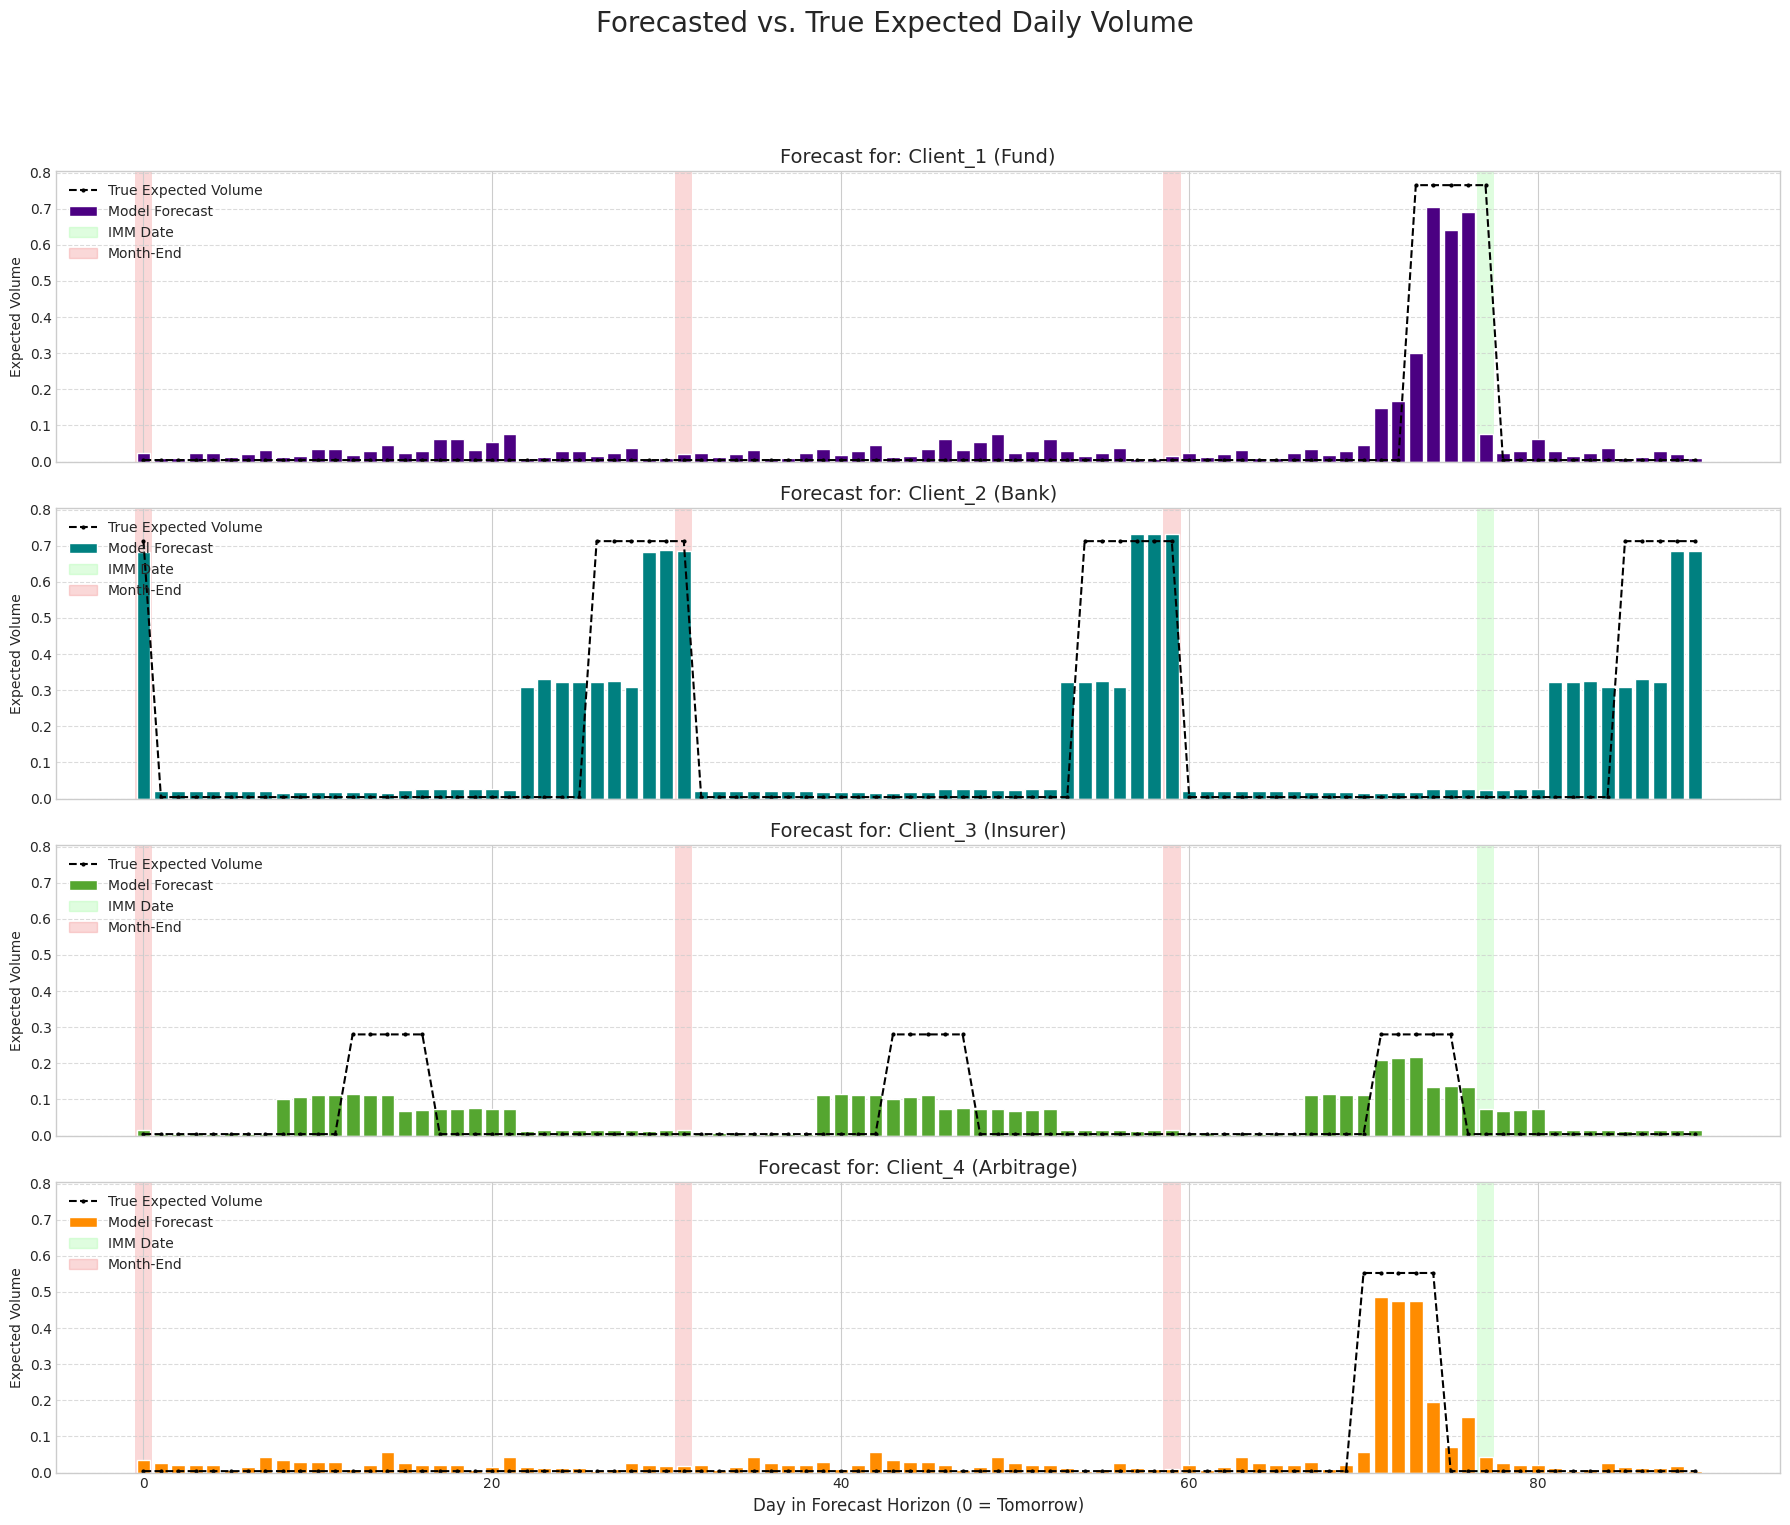


              ANALYSIS OF 'FUND' CLIENT COEFFICIENTS              


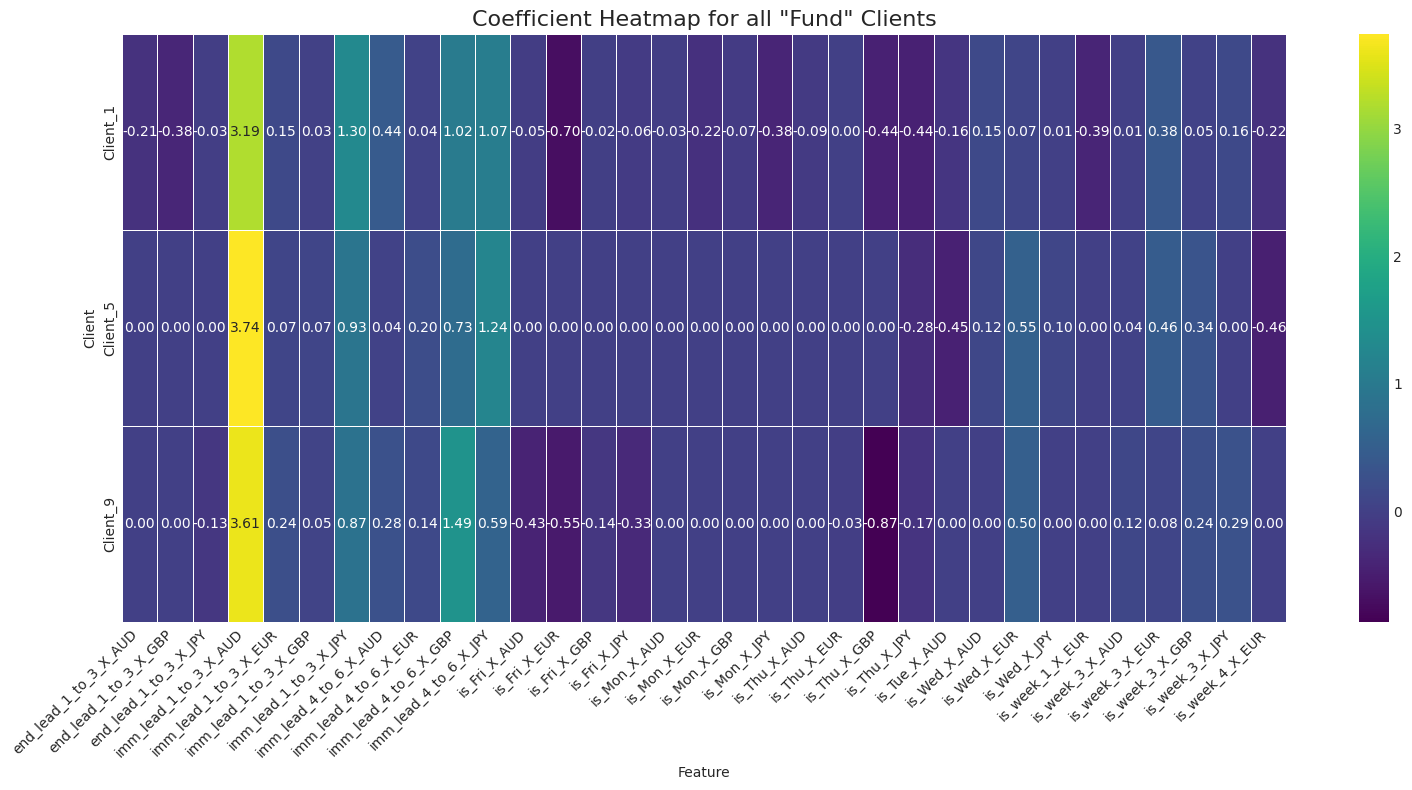


               CLIENT CLUSTERING ANALYSIS (K-MEANS)               


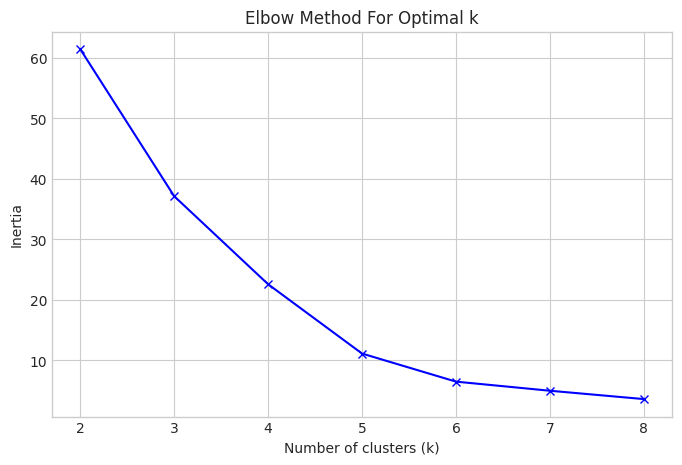


Based on the elbow plot, the optimal number of clusters appears to be 4.


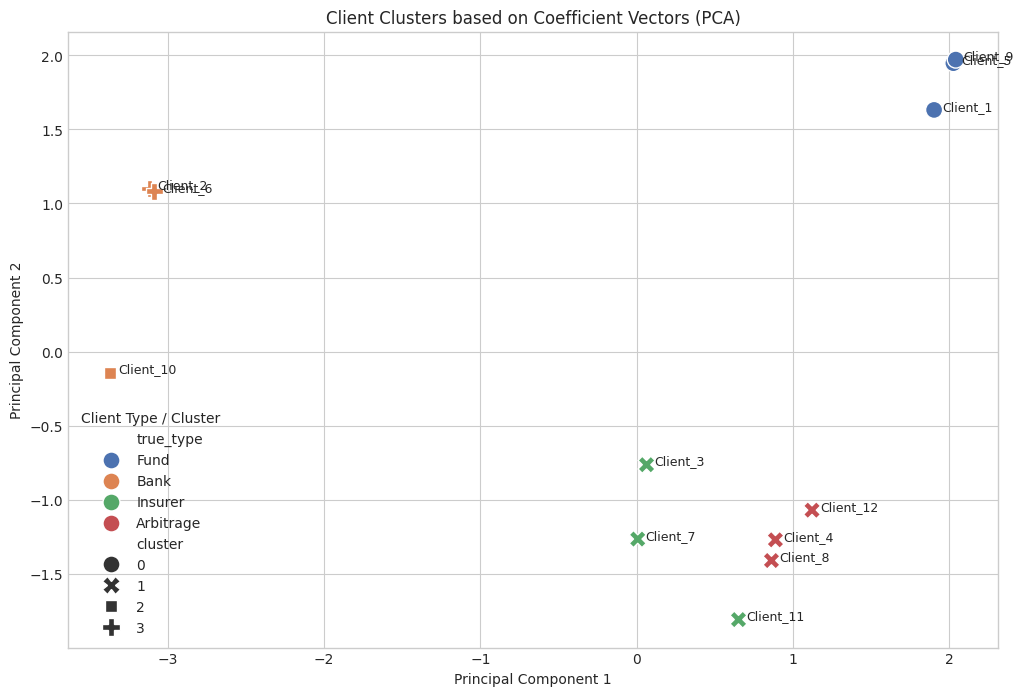


--- Cluster Assignments vs. True Type ---
feature    true_type  cluster
client                       
Client_1        Fund        0
Client_5        Fund        0
Client_9        Fund        0
Client_12  Arbitrage        1
Client_4   Arbitrage        1
Client_3     Insurer        1
Client_7     Insurer        1
Client_11    Insurer        1
Client_8   Arbitrage        1
Client_10       Bank        2
Client_2        Bank        3
Client_6        Bank        3


In [98]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# --- 1. Data Generation with FX Pairs and Volume ---

CLIENTS = [f'Client_{i}' for i in range(1, 13)]
CLIENT_TYPES = ['Fund', 'Bank', 'Insurer', 'Arbitrage']
FX_PAIRS = ['EURUSD', 'GBPUSD', 'USDJPY', 'AUDUSD']
client_to_type_map = {client: CLIENT_TYPES[(i % len(CLIENT_TYPES))] for i, client in enumerate(CLIENTS)}

def is_imm_date(date):
    return date.month in [3, 6, 9, 12] and date.weekday() == 2 and 15 <= date.day <= 21

def generate_trade_events(num_days=2000):
    """
    Generates a DataFrame of simulated trade events with specific patterns,
    including FX pairs and trade volume.
    """
    trade_events = []
    start_date = datetime(2023, 1, 1)

    date_range = pd.to_datetime(pd.date_range(start=start_date, periods=num_days + 10))
    event_dates = pd.DataFrame(index=date_range)
    event_dates['is_imm'] = event_dates.index.map(is_imm_date)
    event_dates['is_mid'] = (event_dates.index.day >= 14) & (event_dates.index.day <= 16)
    event_dates['is_end'] = (event_dates.index + pd.DateOffset(days=3)).month != event_dates.index.month

    for day_offset in range(num_days):
        current_date = start_date + timedelta(days=day_offset)

        for client in CLIENTS:
            client_type = client_to_type_map[client]
            prob = 0.02
            fx_pair = random.choice(FX_PAIRS)
            volume = np.random.uniform(0.1, 0.3)

            if client_type == 'Fund' and any(event_dates.at[current_date + timedelta(days=d), 'is_imm'] for d in range(5)):
                prob = 0.9; volume = np.random.uniform(0.7, 1.0); fx_pair = 'EURUSD'
            elif client_type == 'Bank' and any(event_dates.at[current_date + timedelta(days=d), 'is_end'] for d in range(4)):
                prob = 0.95; volume = np.random.uniform(0.6, 0.9); fx_pair = 'GBPUSD'
            elif client_type == 'Insurer' and any(event_dates.at[current_date + timedelta(days=d), 'is_mid'] for d in range(3)):
                prob = 0.8; volume = np.random.uniform(0.2, 0.5); fx_pair = 'AUDUSD'
            elif client_type == 'Arbitrage' and any(event_dates.at[current_date + timedelta(days=d), 'is_imm'] for d in range(3, 8)):
                prob = 0.85; volume = np.random.uniform(0.5, 0.8); fx_pair = 'USDJPY'

            if random.random() < prob:
                trade_events.append({'time': current_date, 'client': client, 'fx_pair': fx_pair, 'volume': volume})

    return pd.DataFrame(trade_events)

# --- 2. Feature Engineering ---

def create_features_with_interactions(date_series, fx_pairs_list):
    """Creates time-based features and their interactions with FX pairs."""
    time_features_df = pd.DataFrame(index=date_series)
    time_features_df['imm_lead_1_to_3'] = time_features_df.index.map(lambda d: any(is_imm_date(d + timedelta(days=i)) for i in range(1, 4))).astype(int)
    time_features_df['imm_lead_4_to_6'] = time_features_df.index.map(lambda d: any(is_imm_date(d + timedelta(days=i)) for i in range(4, 7))).astype(int)
    time_features_df['end_lead_1_to_3'] = time_features_df.index.map(lambda d: any((d + timedelta(days=i)).month != d.month for i in range(1,4))).astype(int)

    days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
    for i, day_name in enumerate(days):
        time_features_df[f'is_{day_name}'] = (time_features_df.index.dayofweek == i).astype(int)

    for week_num in range(1, 5):
        time_features_df[f'is_week_{week_num}'] = ((time_features_df.index.day - 1) // 7 == week_num - 1).astype(int)

    final_features = pd.DataFrame(index=date_series)
    for pair in fx_pairs_list:
        for time_feature in time_features_df.columns:
            interaction_col_name = f"{time_feature}_X_{pair.replace('USD','')}"
            final_features[interaction_col_name] = time_features_df[time_feature]

    return final_features

# --- 3. Model Training Functions ---

def train_probability_model(X_historical, y_prob, features_to_model):
    """Trains Part 1 of the model and returns the model and its results."""
    model_prob = LogisticRegression(penalty='l1', C=0.5, solver='liblinear', random_state=42)
    model_prob.fit(X_historical, y_prob)

    coeffs = pd.Series(model_prob.coef_[0], index=features_to_model)
    significant_coeffs = coeffs[coeffs.abs() > 0.01]

    intercept_log_odds = model_prob.intercept_[0]
    baseline_prob = 1 / (1 + np.exp(-intercept_log_odds))

    return model_prob, significant_coeffs, baseline_prob

def train_size_model(client_trades):
    """Trains Part 2 of the model and returns the results."""
    if client_trades.empty:
        return {}, None
    averages_by_pair = client_trades.groupby('fx_pair')['volume'].mean().to_dict()
    most_frequent = client_trades['fx_pair'].mode()[0]
    return averages_by_pair, most_frequent

# --- 4. Main Execution: Data, Training, and Analysis ---

# Generate Data
trade_df = generate_trade_events(num_days=1095)
all_days = pd.date_range(start=trade_df['time'].min(), end=trade_df['time'].max())

# Create features for the historical period
X_historical = create_features_with_interactions(all_days, FX_PAIRS)
features_to_model = X_historical.columns.tolist()

# Dictionaries to store models and results
probability_models, volume_averages_by_pair, most_frequent_pair = {}, {}, {}
model_results_list, baseline_results_list = [], []

print("--- Training Two-Part Models for Each Client ---")
for client in CLIENTS:
    client_trades = trade_df[trade_df['client'] == client]
    y_prob = pd.Series(all_days.isin(pd.to_datetime(client_trades['time']))).astype(int)

    model_prob, significant_coeffs, baseline_prob = train_probability_model(X_historical, y_prob, features_to_model)
    probability_models[client] = model_prob
    for feature, coef_val in significant_coeffs.items():
        model_results_list.append({'client': client, 'client_type': client_to_type_map[client], 'feature': feature, 'coefficient': coef_val})
    baseline_results_list.append({'client': client, 'client_type': client_to_type_map[client], 'baseline_probability': baseline_prob})

    volume_averages_by_pair[client], most_frequent_pair[client] = train_size_model(client_trades)

print("Training complete.")

# --- 4a. Model Results Analysis ---
results_df = pd.DataFrame(model_results_list)
print("\n" + "="*70); print("      PART 1: PROBABILITY MODEL RESULTS (ALL COEFFICIENTS)      "); print("="*70)
print(results_df.to_string())
print("\n" + "="*70); print("             PART 2: SIZE MODEL RESULTS (AVERAGES BY PAIR)          "); print("="*70)
volume_summary = [{'client': c, 'client_type': client_to_type_map[c], 'fx_pair': p, 'average_volume': v} for c, d in volume_averages_by_pair.items() for p, v in d.items()]
print(pd.DataFrame(volume_summary).to_string())
print("\n" + "="*70); print("          BASELINE TRADING PROBABILITY (RESIDUAL)          "); print("="*70)
print(pd.DataFrame(baseline_results_list).to_string()); print("="*70 + "\n")


# --- 4b. Coefficient Matrix ---
print("\n" + "="*70); print("                 CLIENT-FEATURE COEFFICIENT MATRIX              "); print("="*70)
coeff_matrix = results_df.pivot_table(index='client', columns='feature', values='coefficient').fillna(0)
print(coeff_matrix)
print("="*70 + "\n")


# --- 5. Forecasting ---

def calculate_true_forecast(future_dates_range, last_date):
    """Calculates the ground truth forecast based on simulation rules."""
    true_forecast_df = pd.DataFrame(index=future_dates_range)
    date_range_future = pd.to_datetime(pd.date_range(start=last_date + timedelta(days=1), periods=len(future_dates_range) + 10))
    event_dates_future = pd.DataFrame(index=date_range_future)
    event_dates_future['is_imm'] = event_dates_future.index.map(is_imm_date)
    event_dates_future['is_mid'] = (event_dates_future.index.day >= 14) & (event_dates_future.index.day <= 16)
    event_dates_future['is_end'] = (event_dates_future.index + pd.DateOffset(days=3)).month != event_dates_future.index.month

    for client_type, client_name in clients_to_predict.items():
        true_volumes = []
        for date in future_dates_range:
            true_prob, true_vol = 0.02, 0.2
            if client_type == 'Fund' and any(event_dates_future.at[date + timedelta(days=d), 'is_imm'] for d in range(5)):
                true_prob, true_vol = 0.9, 0.85
            elif client_type == 'Bank' and any(event_dates_future.at[date + timedelta(days=d), 'is_end'] for d in range(4)):
                true_prob, true_vol = 0.95, 0.75
            elif client_type == 'Insurer' and any(event_dates_future.at[date + timedelta(days=d), 'is_mid'] for d in range(3)):
                true_prob, true_vol = 0.8, 0.35
            elif client_type == 'Arbitrage' and any(event_dates_future.at[date + timedelta(days=d), 'is_imm'] for d in range(3, 8)):
                true_prob, true_vol = 0.85, 0.65
            true_volumes.append(true_prob * true_vol)
        true_forecast_df[f'{client_name}_{client_type}'] = true_volumes
    return true_forecast_df

last_date = all_days.max()
future_dates_range = pd.date_range(start=last_date + timedelta(days=1), periods=90)
X_future = create_features_with_interactions(future_dates_range, FX_PAIRS)[features_to_model]

clients_to_predict = {'Fund': 'Client_1', 'Bank': 'Client_2', 'Insurer': 'Client_3', 'Arbitrage': 'Client_4'}
prediction_df = pd.DataFrame(index=future_dates_range)

for client_type, client_name in clients_to_predict.items():
    if client_name in probability_models:
        prob_model = probability_models[client_name]
        trade_probabilities = prob_model.predict_proba(X_future)[:, 1]
        primary_pair = most_frequent_pair.get(client_name)
        avg_volume = volume_averages_by_pair.get(client_name, {}).get(primary_pair, 0)
        prediction_df[f'{client_name}_{client_type}'] = trade_probabilities * avg_volume

# --- 6. Visualization ---

def plot_forecasts(prediction_df, true_forecast_df=None):
    """Visualizes the model's forecast, optionally with a ground truth comparison."""
    client_colors = {'Fund': '#4b0082', 'Bank': '#008080', 'Insurer': '#55a630', 'Arbitrage': '#ff8c00'}
    region_colors = {'IMM Date': 'palegreen', 'Month-End': 'lightcoral'}
    num_clients = len(clients_to_predict)

    fig, axes = plt.subplots(num_clients, 1, figsize=(18, 4 * num_clients), sharex=True, sharey=True)
    title = 'Forecasted vs. True Expected Daily Volume' if true_forecast_df is not None else 'Forecasted Expected Daily Volume'
    fig.suptitle(title, fontsize=20, y=0.95)

    prediction_df_reset = prediction_df.reset_index().rename(columns={'index': 'date'})
    if true_forecast_df is not None:
        true_forecast_df_reset = true_forecast_df.reset_index().rename(columns={'index': 'date'})

    shading_features = pd.DataFrame(index=prediction_df_reset['date'])
    shading_features['is_imm_date'] = shading_features.index.map(is_imm_date)
    shading_features['is_month_end'] = shading_features.index.is_month_end

    for i, (client_type, client_name) in enumerate(clients_to_predict.items()):
        ax = axes[i]
        col_name = f'{client_name}_{client_type}'

        ax.bar(prediction_df_reset.index, prediction_df_reset[col_name], color=client_colors[client_type], label=f'Model Forecast')

        if true_forecast_df is not None:
            ax.plot(true_forecast_df_reset.index, true_forecast_df_reset[col_name], color='black', linestyle='--', marker='.', markersize=4, label='True Expected Volume')

        for idx, row in shading_features.reset_index().iterrows():
            if row['is_imm_date']: ax.axvspan(idx - 0.5, idx + 0.5, color=region_colors['IMM Date'], alpha=0.3, zorder=0, lw=0)
            if row['is_month_end']: ax.axvspan(idx - 0.5, idx + 0.5, color=region_colors['Month-End'], alpha=0.3, zorder=0, lw=0)

        ax.set_title(f'Forecast for: {client_name} ({client_type})', fontsize=14); ax.set_ylabel('Expected Volume'); ax.grid(axis='y', linestyle='--', alpha=0.7)

        handles, labels = ax.get_legend_handles_labels()
        if true_forecast_df is not None:
            region_patches = [plt.Rectangle((0,0),1,1, color=color, alpha=0.3) for color in region_colors.values()]
            handles.extend(region_patches); labels.extend(region_colors.keys())
        ax.legend(handles=handles, labels=labels, loc='upper left')

    axes[-1].set_xlabel('Day in Forecast Horizon (0 = Tomorrow)', fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()

# --- Run Main Visualization ---
true_forecast = calculate_true_forecast(future_dates_range, last_date)
plot_forecasts(prediction_df, true_forecast_df=true_forecast)

# --- 7. Fund Client Analysis Visualization ---
print("\n" + "="*70); print("              ANALYSIS OF 'FUND' CLIENT COEFFICIENTS              "); print("="*70)
fund_clients = [client for client, ctype in client_to_type_map.items() if ctype == 'Fund']
fund_coeffs = coeff_matrix.loc[fund_clients]

# Select only features where at least one fund has a non-zero coefficient
fund_coeffs = fund_coeffs.loc[:, (fund_coeffs != 0).any(axis=0)]

plt.figure(figsize=(16, 8))
sns.heatmap(fund_coeffs, cmap='viridis', annot=True, fmt='.2f', linewidths=.5)
plt.title('Coefficient Heatmap for all "Fund" Clients', fontsize=16)
plt.xlabel('Feature')
plt.ylabel('Client')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- 8. ADDED: Client Clustering Analysis ---
print("\n" + "="*70); print("               CLIENT CLUSTERING ANALYSIS (K-MEANS)               "); print("="*70)

# Elbow method to find optimal k
inertia = []
K = range(2, 9)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(coeff_matrix)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

# Based on the elbow plot, choose the optimal k (usually 4 for this dataset)
optimal_k = 4
print(f"\nBased on the elbow plot, the optimal number of clusters appears to be {optimal_k}.")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(coeff_matrix)
coeff_matrix['cluster'] = clusters
coeff_matrix['true_type'] = coeff_matrix.index.map(client_to_type_map)

# Visualize clusters with PCA
pca = PCA(n_components=2, random_state=42)
principal_components = pca.fit_transform(coeff_matrix.drop(columns=['cluster', 'true_type']))
pca_df = pd.DataFrame(data=principal_components, columns=['PC 1', 'PC 2'], index=coeff_matrix.index)
pca_df = pd.concat([pca_df, coeff_matrix[['cluster', 'true_type']]], axis=1)

plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC 1', y='PC 2', hue='true_type', style='cluster', data=pca_df, s=150, palette='deep')
# Add client labels
for i, client in enumerate(pca_df.index):
    plt.text(pca_df['PC 1'][i]+0.05, pca_df['PC 2'][i], client, fontsize=9)

plt.title('Client Clusters based on Coefficient Vectors (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Client Type / Cluster')
plt.grid(True)
plt.show()

print("\n--- Cluster Assignments vs. True Type ---")
print(coeff_matrix[['true_type', 'cluster']].sort_values(by='cluster'))


--- Training Two-Part Models for Each Client using Mutual Information ---
Training complete.

    TOP FEATURES IDENTIFIED BY MUTUAL INFORMATION (PER CLIENT)    
       client client_type                feature  mi_score
0    Client_1        Fund  imm_lead_1_to_3_X_JPY  0.074345
1    Client_1        Fund  imm_lead_1_to_3_X_AUD  0.073169
2    Client_1        Fund  imm_lead_1_to_3_X_GBP  0.071082
3    Client_1        Fund  imm_lead_1_to_3_X_EUR  0.070996
4    Client_1        Fund        is_week_3_X_EUR  0.035591
5    Client_1        Fund        is_week_3_X_GBP  0.032393
6    Client_1        Fund        is_week_3_X_AUD  0.032004
7    Client_1        Fund        is_week_3_X_JPY  0.028934
8    Client_2        Bank  end_lead_1_to_3_X_AUD  0.143273
9    Client_2        Bank  end_lead_1_to_3_X_EUR  0.142630
10   Client_2        Bank  end_lead_1_to_3_X_GBP  0.139716
11   Client_2        Bank  end_lead_1_to_3_X_JPY  0.138631
12   Client_2        Bank        is_week_4_X_JPY  0.079244
13   Client_2

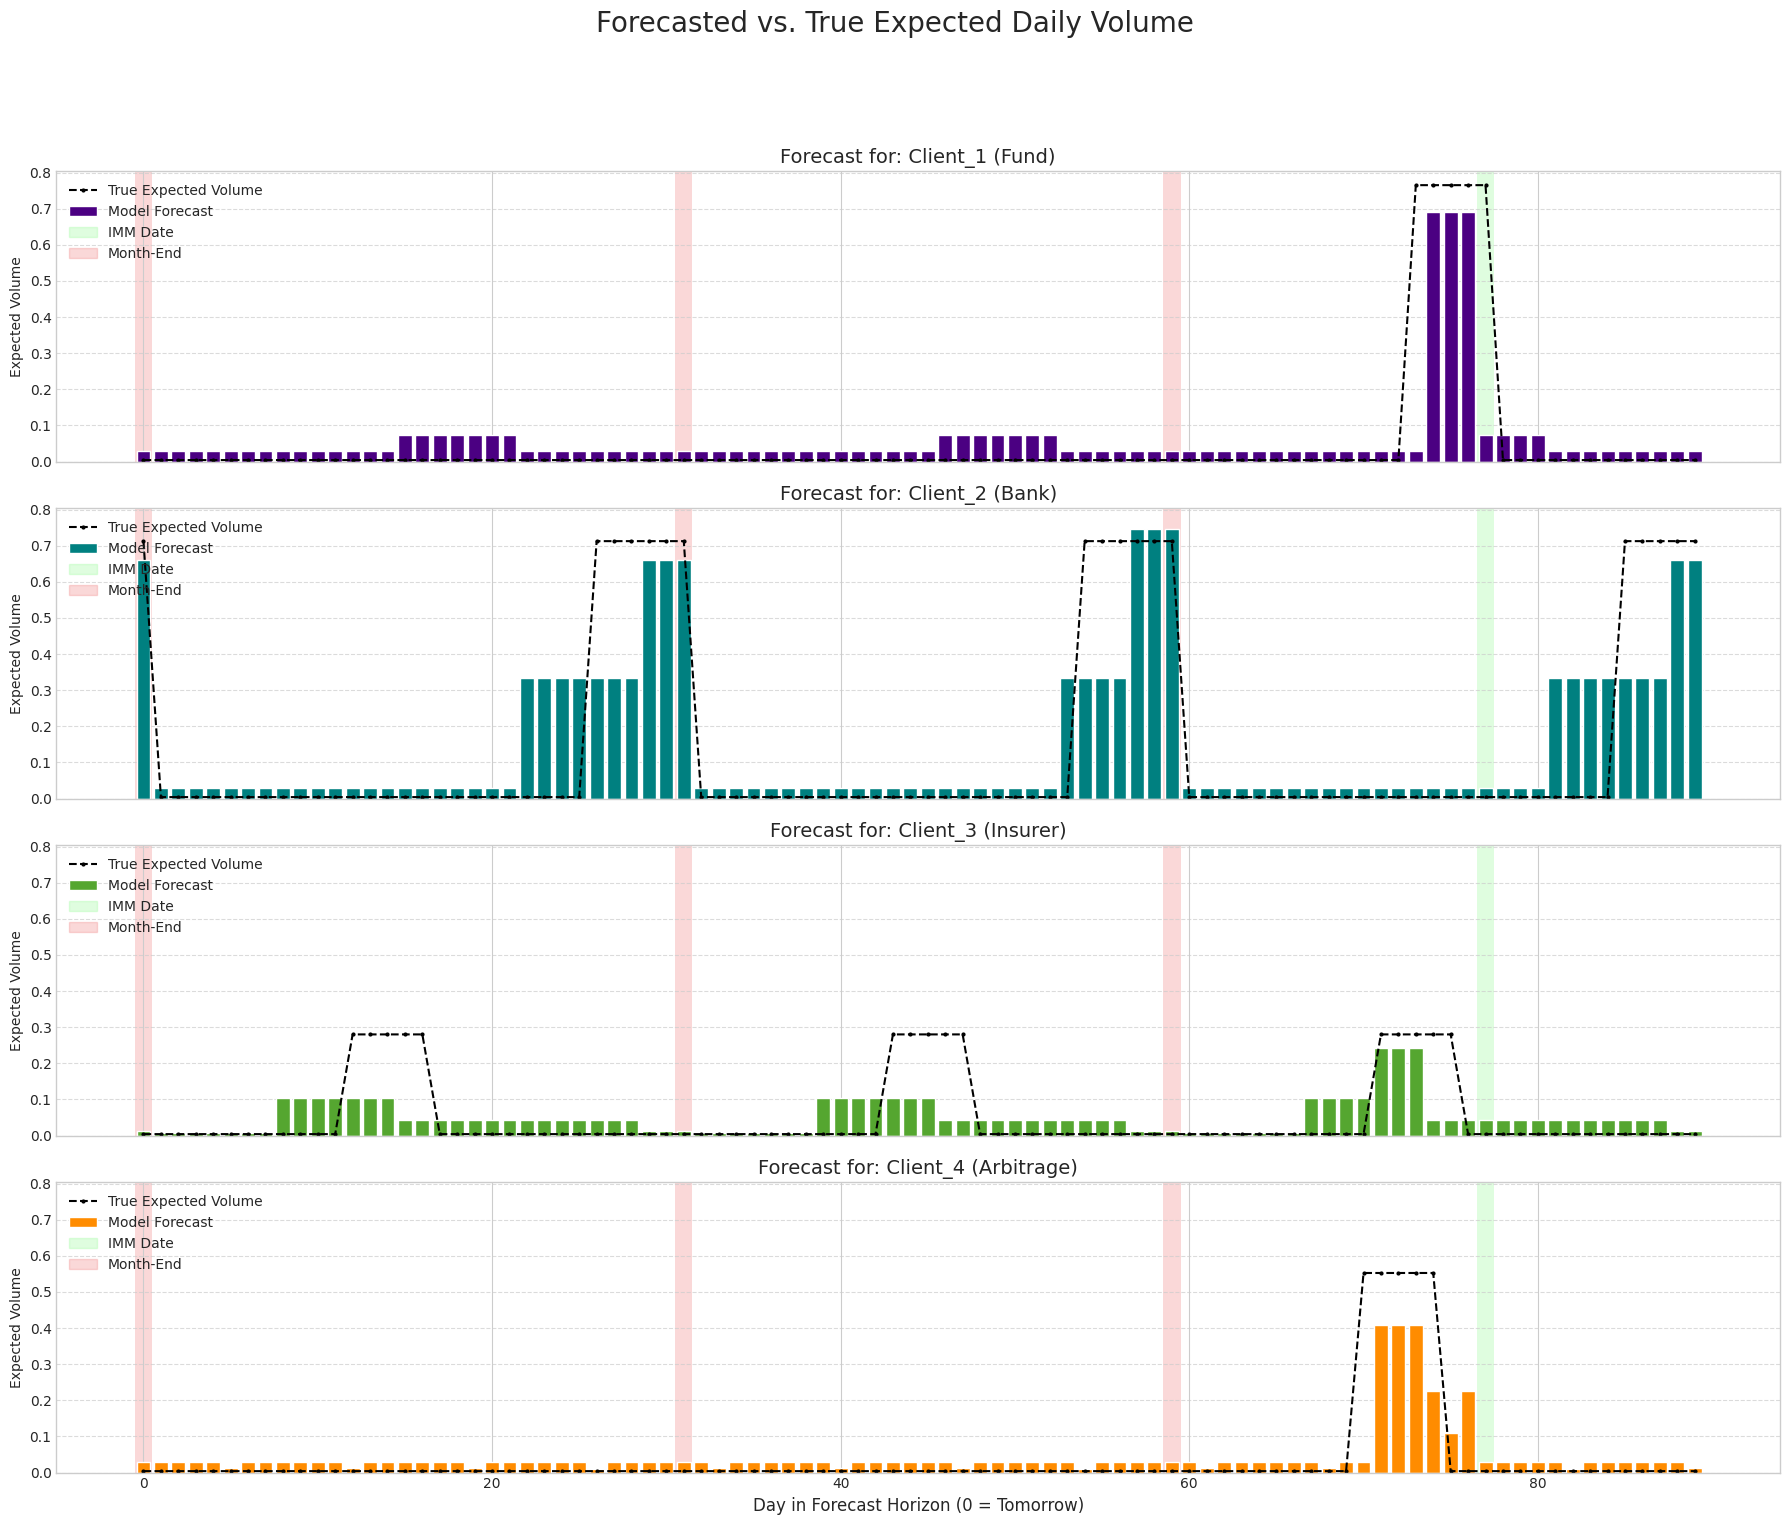

In [99]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
# --- ADDED IMPORTS ---
from sklearn.feature_selection import mutual_info_classif, SelectKBest

# --- 1. Data Generation with FX Pairs and Volume (No Changes) ---

CLIENTS = [f'Client_{i}' for i in range(1, 13)]
CLIENT_TYPES = ['Fund', 'Bank', 'Insurer', 'Arbitrage']
FX_PAIRS = ['EURUSD', 'GBPUSD', 'USDJPY', 'AUDUSD']
client_to_type_map = {client: CLIENT_TYPES[(i % len(CLIENT_TYPES))] for i, client in enumerate(CLIENTS)}

def is_imm_date(date):
    return date.month in [3, 6, 9, 12] and date.weekday() == 2 and 15 <= date.day <= 21

def generate_trade_events(num_days=2000):
    """
    Generates a DataFrame of simulated trade events with specific patterns,
    including FX pairs and trade volume.
    """
    trade_events = []
    start_date = datetime(2023, 1, 1)

    date_range = pd.to_datetime(pd.date_range(start=start_date, periods=num_days + 10))
    event_dates = pd.DataFrame(index=date_range)
    event_dates['is_imm'] = event_dates.index.map(is_imm_date)
    event_dates['is_mid'] = (event_dates.index.day >= 14) & (event_dates.index.day <= 16)
    event_dates['is_end'] = (event_dates.index + pd.DateOffset(days=3)).month != event_dates.index.month

    for day_offset in range(num_days):
        current_date = start_date + timedelta(days=day_offset)

        for client in CLIENTS:
            client_type = client_to_type_map[client]
            prob = 0.02
            fx_pair = random.choice(FX_PAIRS)
            volume = np.random.uniform(0.1, 0.3)

            if client_type == 'Fund' and any(event_dates.at[current_date + timedelta(days=d), 'is_imm'] for d in range(5)):
                prob = 0.9; volume = np.random.uniform(0.7, 1.0); fx_pair = 'EURUSD'
            elif client_type == 'Bank' and any(event_dates.at[current_date + timedelta(days=d), 'is_end'] for d in range(4)):
                prob = 0.95; volume = np.random.uniform(0.6, 0.9); fx_pair = 'GBPUSD'
            elif client_type == 'Insurer' and any(event_dates.at[current_date + timedelta(days=d), 'is_mid'] for d in range(3)):
                prob = 0.8; volume = np.random.uniform(0.2, 0.5); fx_pair = 'AUDUSD'
            elif client_type == 'Arbitrage' and any(event_dates.at[current_date + timedelta(days=d), 'is_imm'] for d in range(3, 8)):
                prob = 0.85; volume = np.random.uniform(0.5, 0.8); fx_pair = 'USDJPY'

            if random.random() < prob:
                trade_events.append({'time': current_date, 'client': client, 'fx_pair': fx_pair, 'volume': volume})

    return pd.DataFrame(trade_events)

# --- 2. Feature Engineering (No Changes) ---

def create_features_with_interactions(date_series, fx_pairs_list):
    """Creates time-based features and their interactions with FX pairs."""
    time_features_df = pd.DataFrame(index=date_series)
    time_features_df['imm_lead_1_to_3'] = time_features_df.index.map(lambda d: any(is_imm_date(d + timedelta(days=i)) for i in range(1, 4))).astype(int)
    time_features_df['imm_lead_4_to_6'] = time_features_df.index.map(lambda d: any(is_imm_date(d + timedelta(days=i)) for i in range(4, 7))).astype(int)
    time_features_df['end_lead_1_to_3'] = time_features_df.index.map(lambda d: any((d + timedelta(days=i)).month != d.month for i in range(1,4))).astype(int)

    days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
    for i, day_name in enumerate(days):
        time_features_df[f'is_{day_name}'] = (time_features_df.index.dayofweek == i).astype(int)

    for week_num in range(1, 5):
        time_features_df[f'is_week_{week_num}'] = ((time_features_df.index.day - 1) // 7 == week_num - 1).astype(int)

    final_features = pd.DataFrame(index=date_series)
    for pair in fx_pairs_list:
        for time_feature in time_features_df.columns:
            interaction_col_name = f"{time_feature}_X_{pair.replace('USD','')}"
            final_features[interaction_col_name] = time_features_df[time_feature]

    return final_features

# --- 3. MODIFIED Model Training Functions ---

# --- NEW FUNCTION: Feature Selection with Mutual Information ---
def select_features_with_mi(X, y, k=10):
    """
    Selects the top k features based on mutual information scores.
    Returns a DataFrame with selected features and a list of their names.
    """
    # Calculate MI scores
    mi_scores = mutual_info_classif(X, y, random_state=42)
    mi_series = pd.Series(mi_scores, index=X.columns)
    mi_series = mi_series.sort_values(ascending=False)

    # Select top k features
    top_k_features = mi_series.head(k).index.tolist()
    X_selected = X[top_k_features]

    # For analysis, let's return the scores too
    return X_selected, top_k_features, mi_series.head(k)


def train_probability_model(X_historical, y_prob, features_to_model):
    """
    Trains Part 1 of the model and returns the model and its results.
    MODIFIED: Uses L2 regularization as features are pre-selected.
    """
    # Switched penalty to 'l2' (Ridge). C=0.5 is a reasonable default.
    model_prob = LogisticRegression(penalty='l2', C=0.5, solver='liblinear', random_state=42)
    model_prob.fit(X_historical, y_prob)

    coeffs = pd.Series(model_prob.coef_[0], index=features_to_model)
    # With L2, coeffs don't go to zero, so we show all of them for the selected features.
    significant_coeffs = coeffs

    intercept_log_odds = model_prob.intercept_[0]
    baseline_prob = 1 / (1 + np.exp(-intercept_log_odds))

    return model_prob, significant_coeffs, baseline_prob

def train_size_model(client_trades):
    """Trains Part 2 of the model and returns the results."""
    if client_trades.empty:
        return {}, None
    averages_by_pair = client_trades.groupby('fx_pair')['volume'].mean().to_dict()
    most_frequent = client_trades['fx_pair'].mode()[0]
    return averages_by_pair, most_frequent

# --- 4. MODIFIED Main Execution: Data, Training, and Analysis ---

# Generate Data
trade_df = generate_trade_events(num_days=1095)
all_days = pd.date_range(start=trade_df['time'].min(), end=trade_df['time'].max())

# Create ALL possible features for the historical period
X_historical_full = create_features_with_interactions(all_days, FX_PAIRS)

# Dictionaries to store models, results, and selected features for each client
probability_models, volume_averages_by_pair, most_frequent_pair = {}, {}, {}
model_results_list, baseline_results_list = [], []
client_feature_selectors = {} # Store the selected features for each client for forecasting

# --- NEW: Store MI scores for analysis ---
all_mi_scores = {}

# The number of features to select. This is a hyperparameter you can tune.
# Let's choose 8 for this example.
NUM_FEATURES_TO_SELECT = 8

print("--- Training Two-Part Models for Each Client using Mutual Information ---")
for client in CLIENTS:
    client_trades = trade_df[trade_df['client'] == client]
    y_prob = pd.Series(all_days.isin(pd.to_datetime(client_trades['time']))).astype(int)

    # --- NEW: FEATURE SELECTION STEP ---
    X_historical_selected, selected_feature_names, top_mi_scores = select_features_with_mi(
        X_historical_full, y_prob, k=NUM_FEATURES_TO_SELECT
    )
    all_mi_scores[client] = top_mi_scores # Store scores for analysis
    client_feature_selectors[client] = selected_feature_names # Save for forecasting

    # --- MODIFIED: Train model on SELECTED features ---
    model_prob, significant_coeffs, baseline_prob = train_probability_model(
        X_historical_selected, y_prob, selected_feature_names
    )

    probability_models[client] = model_prob
    for feature, coef_val in significant_coeffs.items():
        model_results_list.append({'client': client, 'client_type': client_to_type_map[client], 'feature': feature, 'coefficient': coef_val})
    baseline_results_list.append({'client': client, 'client_type': client_to_type_map[client], 'baseline_probability': baseline_prob})

    volume_averages_by_pair[client], most_frequent_pair[client] = train_size_model(client_trades)

print("Training complete.")


# --- 4a. MODIFIED: Model Results Analysis ---
# --- NEW: Displaying Mutual Information Scores ---
print("\n" + "="*70); print("    TOP FEATURES IDENTIFIED BY MUTUAL INFORMATION (PER CLIENT)    "); print("="*70)
mi_results_list = []
for client, scores in all_mi_scores.items():
    for feature, score in scores.items():
        mi_results_list.append({
            'client': client,
            'client_type': client_to_type_map[client],
            'feature': feature,
            'mi_score': score
        })
mi_df = pd.DataFrame(mi_results_list)
print(mi_df.to_string())


results_df = pd.DataFrame(model_results_list)
print("\n" + "="*70); print("      PART 1: PROBABILITY MODEL RESULTS (ALL COEFFICIENTS)      "); print("="*70)
print(results_df.to_string())
print("\n" + "="*70); print("             PART 2: SIZE MODEL RESULTS (AVERAGES BY PAIR)          "); print("="*70)
volume_summary = [{'client': c, 'client_type': client_to_type_map[c], 'fx_pair': p, 'average_volume': v} for c, d in volume_averages_by_pair.items() for p, v in d.items()]
print(pd.DataFrame(volume_summary).to_string())
print("\n" + "="*70); print("          BASELINE TRADING PROBABILITY (RESIDUAL)          "); print("="*70)
print(pd.DataFrame(baseline_results_list).to_string()); print("="*70 + "\n")

# --- 4b. Coefficient Matrix ---
print("\n" + "="*70); print("                 CLIENT-FEATURE COEFFICIENT MATRIX              "); print("="*70)
coeff_matrix = results_df.pivot_table(index='client', columns='feature', values='coefficient').fillna(0)
print(coeff_matrix)
print("="*70 + "\n")


# --- 5. MODIFIED: Forecasting ---

def calculate_true_forecast(future_dates_range, last_date):
    """Calculates the ground truth forecast based on simulation rules."""
    true_forecast_df = pd.DataFrame(index=future_dates_range)
    date_range_future = pd.to_datetime(pd.date_range(start=last_date + timedelta(days=1), periods=len(future_dates_range) + 10))
    event_dates_future = pd.DataFrame(index=date_range_future)
    event_dates_future['is_imm'] = event_dates_future.index.map(is_imm_date)
    event_dates_future['is_mid'] = (event_dates_future.index.day >= 14) & (event_dates_future.index.day <= 16)
    event_dates_future['is_end'] = (event_dates_future.index + pd.DateOffset(days=3)).month != event_dates_future.index.month

    for client_type, client_name in clients_to_predict.items():
        true_volumes = []
        for date in future_dates_range:
            true_prob, true_vol = 0.02, 0.2
            if client_type == 'Fund' and any(event_dates_future.at[date + timedelta(days=d), 'is_imm'] for d in range(5)):
                true_prob, true_vol = 0.9, 0.85
            elif client_type == 'Bank' and any(event_dates_future.at[date + timedelta(days=d), 'is_end'] for d in range(4)):
                true_prob, true_vol = 0.95, 0.75
            elif client_type == 'Insurer' and any(event_dates_future.at[date + timedelta(days=d), 'is_mid'] for d in range(3)):
                true_prob, true_vol = 0.8, 0.35
            elif client_type == 'Arbitrage' and any(event_dates_future.at[date + timedelta(days=d), 'is_imm'] for d in range(3, 8)):
                true_prob, true_vol = 0.85, 0.65
            true_volumes.append(true_prob * true_vol)
        true_forecast_df[f'{client_name}_{client_type}'] = true_volumes
    return true_forecast_df

last_date = all_days.max()
future_dates_range = pd.date_range(start=last_date + timedelta(days=1), periods=90)
# Create all features first
X_future_full = create_features_with_interactions(future_dates_range, FX_PAIRS)

clients_to_predict = {'Fund': 'Client_1', 'Bank': 'Client_2', 'Insurer': 'Client_3', 'Arbitrage': 'Client_4'}
prediction_df = pd.DataFrame(index=future_dates_range)

for client_type, client_name in clients_to_predict.items():
    if client_name in probability_models:
        prob_model = probability_models[client_name]

        # --- MODIFIED: Select the same features for the future data ---
        selected_features = client_feature_selectors[client_name]
        X_future_selected = X_future_full[selected_features]

        trade_probabilities = prob_model.predict_proba(X_future_selected)[:, 1]
        primary_pair = most_frequent_pair.get(client_name)
        avg_volume = volume_averages_by_pair.get(client_name, {}).get(primary_pair, 0)
        prediction_df[f'{client_name}_{client_type}'] = trade_probabilities * avg_volume

# --- 6. Visualization (No Changes to plotting function) ---
def plot_forecasts(prediction_df, true_forecast_df=None):
    """Visualizes the model's forecast, optionally with a ground truth comparison."""
    client_colors = {'Fund': '#4b0082', 'Bank': '#008080', 'Insurer': '#55a630', 'Arbitrage': '#ff8c00'}
    region_colors = {'IMM Date': 'palegreen', 'Month-End': 'lightcoral'}
    num_clients = len(clients_to_predict)

    fig, axes = plt.subplots(num_clients, 1, figsize=(18, 4 * num_clients), sharex=True, sharey=True)
    title = 'Forecasted vs. True Expected Daily Volume' if true_forecast_df is not None else 'Forecasted Expected Daily Volume'
    fig.suptitle(title, fontsize=20, y=0.95)

    prediction_df_reset = prediction_df.reset_index().rename(columns={'index': 'date'})
    if true_forecast_df is not None:
        true_forecast_df_reset = true_forecast_df.reset_index().rename(columns={'index': 'date'})

    shading_features = pd.DataFrame(index=prediction_df_reset['date'])
    shading_features['is_imm_date'] = shading_features.index.map(is_imm_date)
    shading_features['is_month_end'] = shading_features.index.is_month_end

    for i, (client_type, client_name) in enumerate(clients_to_predict.items()):
        ax = axes[i]
        col_name = f'{client_name}_{client_type}'

        ax.bar(prediction_df_reset.index, prediction_df_reset[col_name], color=client_colors[client_type], label=f'Model Forecast')

        if true_forecast_df is not None:
            ax.plot(true_forecast_df_reset.index, true_forecast_df_reset[col_name], color='black', linestyle='--', marker='.', markersize=4, label='True Expected Volume')

        for idx, row in shading_features.reset_index().iterrows():
            if row['is_imm_date']: ax.axvspan(idx - 0.5, idx + 0.5, color=region_colors['IMM Date'], alpha=0.3, zorder=0, lw=0)
            if row['is_month_end']: ax.axvspan(idx - 0.5, idx + 0.5, color=region_colors['Month-End'], alpha=0.3, zorder=0, lw=0)

        ax.set_title(f'Forecast for: {client_name} ({client_type})', fontsize=14); ax.set_ylabel('Expected Volume'); ax.grid(axis='y', linestyle='--', alpha=0.7)

        handles, labels = ax.get_legend_handles_labels()
        if true_forecast_df is not None:
            region_patches = [plt.Rectangle((0,0),1,1, color=color, alpha=0.3) for color in region_colors.values()]
            handles.extend(region_patches); labels.extend(region_colors.keys())
        ax.legend(handles=handles, labels=labels, loc='upper left')

    axes[-1].set_xlabel('Day in Forecast Horizon (0 = Tomorrow)', fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()

# --- Run Main Visualization ---
true_forecast = calculate_true_forecast(future_dates_range, last_date)
plot_forecasts(prediction_df, true_forecast_df=true_forecast)

# --- 7, 8... The rest of the analysis code can run as is, but the results will be based on the new model ---
# The coefficient matrix will be different (denser, but with fewer features).
# The clustering will be based on these new coefficient vectors.

--- Training Two-Part Models for Each Client using mRMR Feature Selection ---


100%|██████████| 10/10 [00:01<00:00,  8.93it/s]


Training complete.

           FEATURES SELECTED BY mRMR (PER CLIENT)             
rank                                      1                      2                      3                      4                      5                      6                      7                      8                      9                      10
client    client_type                                                                                                                                                                                                                                      
Client_1  Fund         imm_lead_1_to_3_X_EUR  imm_lead_4_to_6_X_EUR  imm_lead_1_to_3_X_GBP  imm_lead_1_to_3_X_JPY  imm_lead_1_to_3_X_AUD        is_week_3_X_EUR        is_week_3_X_GBP  imm_lead_4_to_6_X_GBP        is_week_3_X_JPY        is_week_3_X_AUD
Client_10 Bank         end_lead_1_to_3_X_EUR        is_week_4_X_EUR  end_lead_1_to_3_X_GBP  end_lead_1_to_3_X_JPY  end_lead_1_to_3_X_AUD        is_week_4_X_GBP  

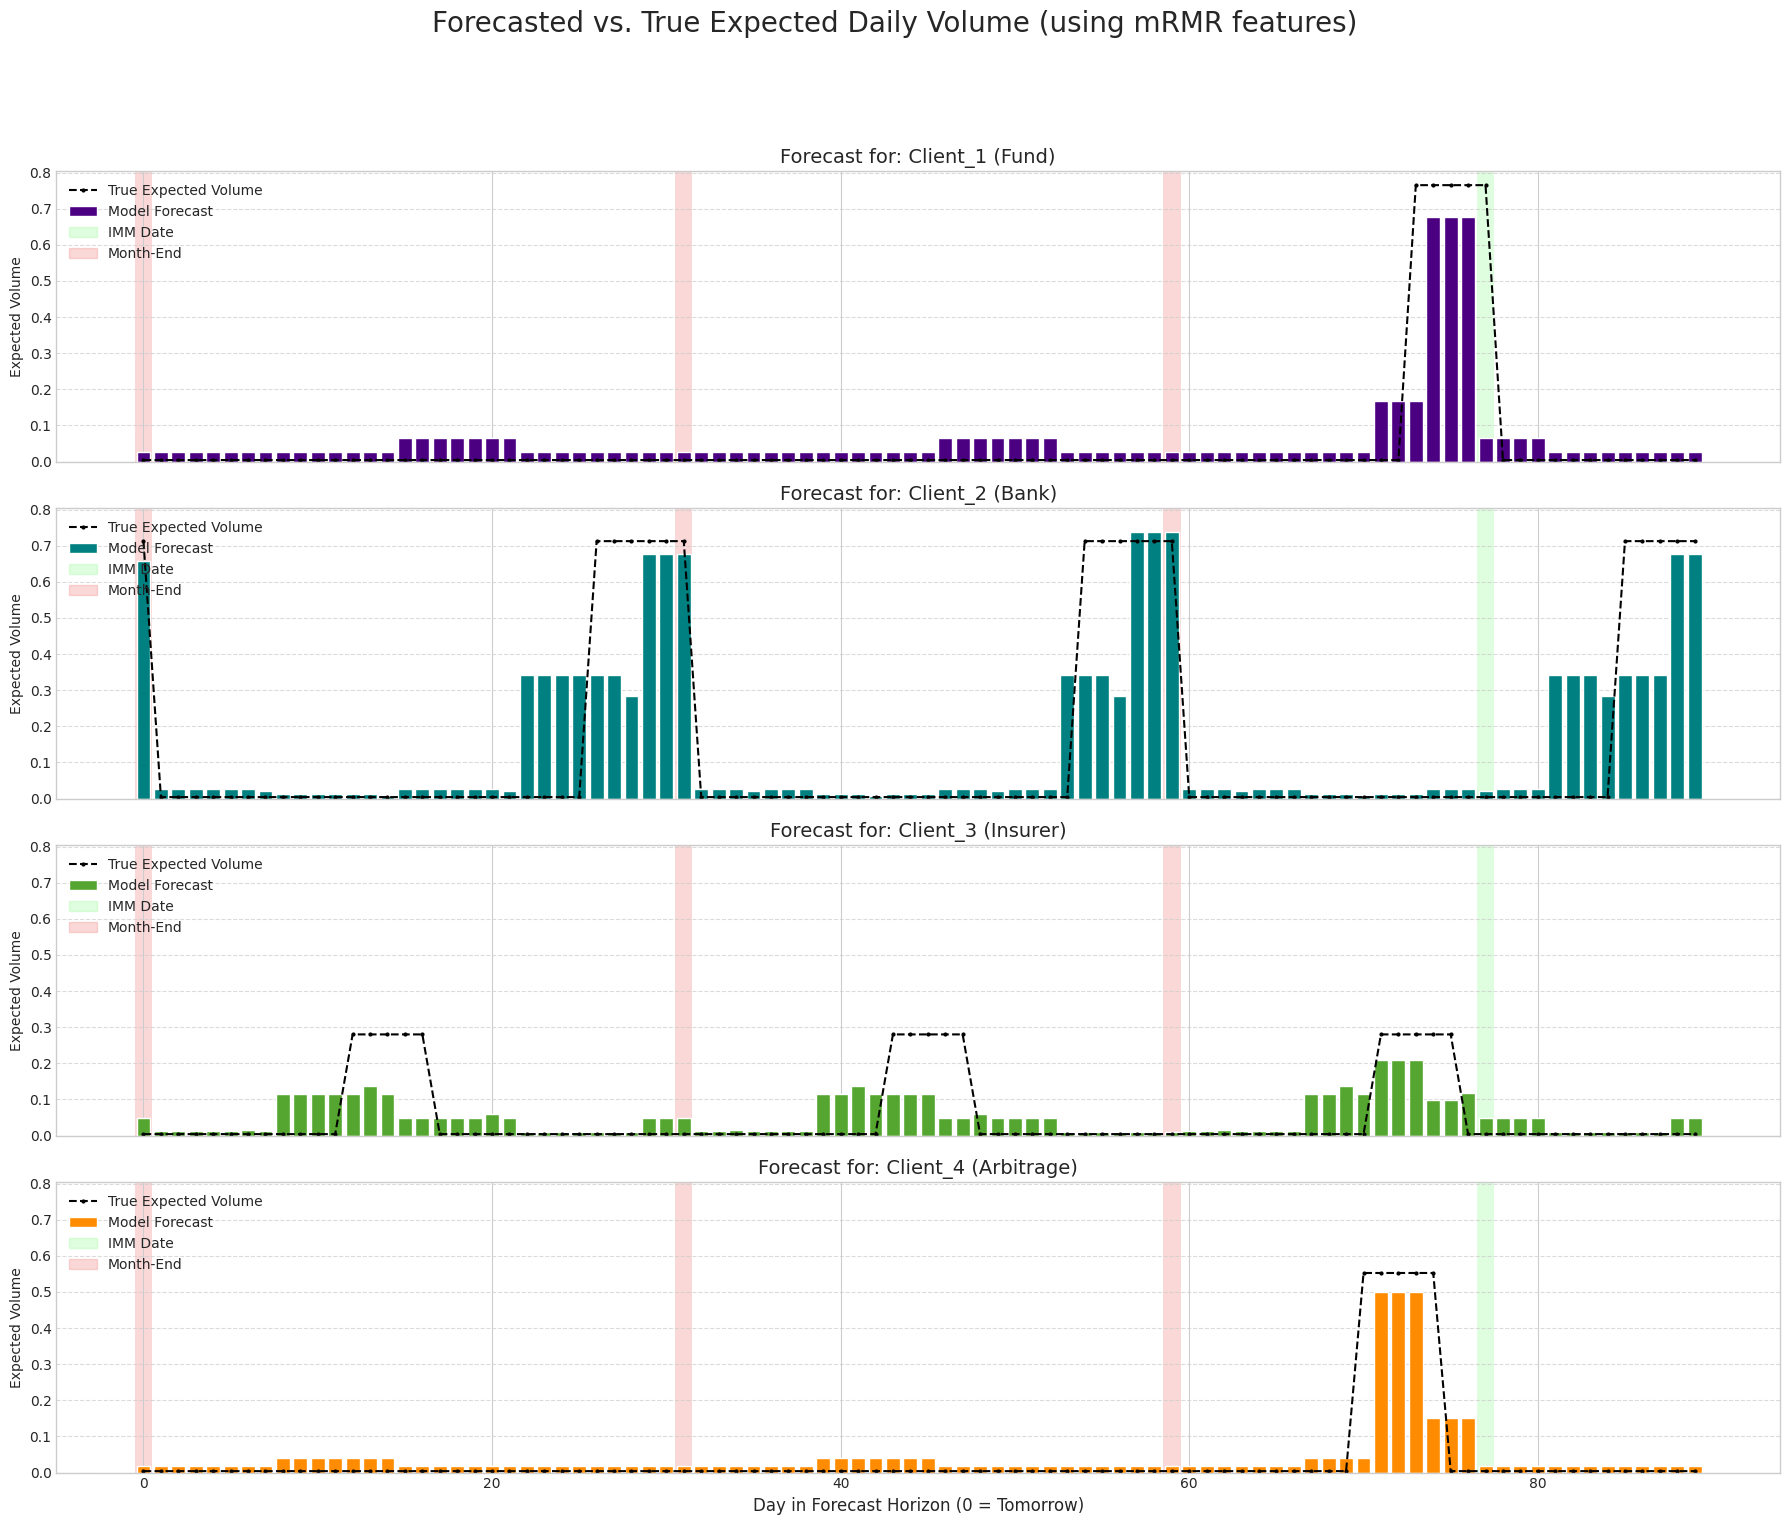


              ANALYSIS OF 'FUND' CLIENT COEFFICIENTS              


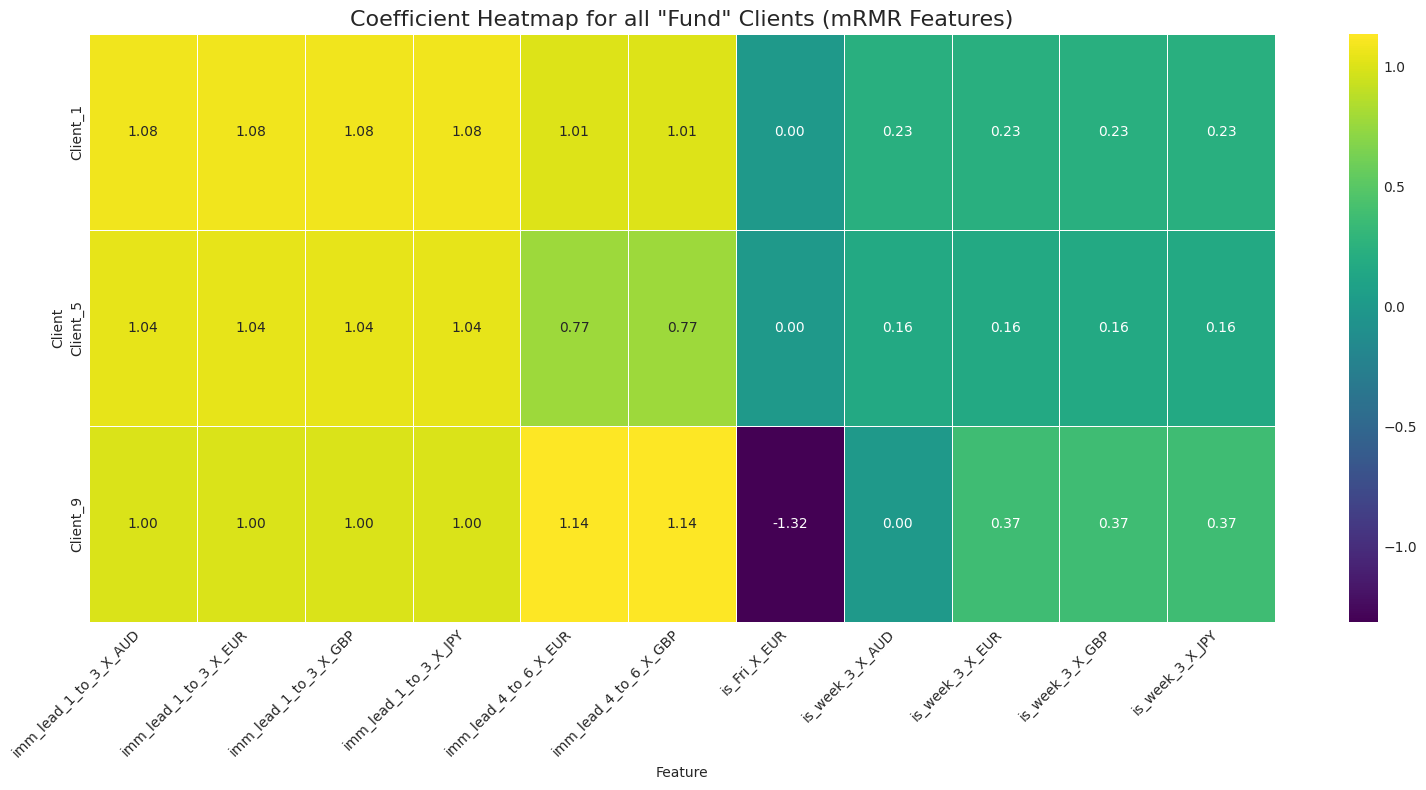


               CLIENT CLUSTERING ANALYSIS (K-MEANS)               


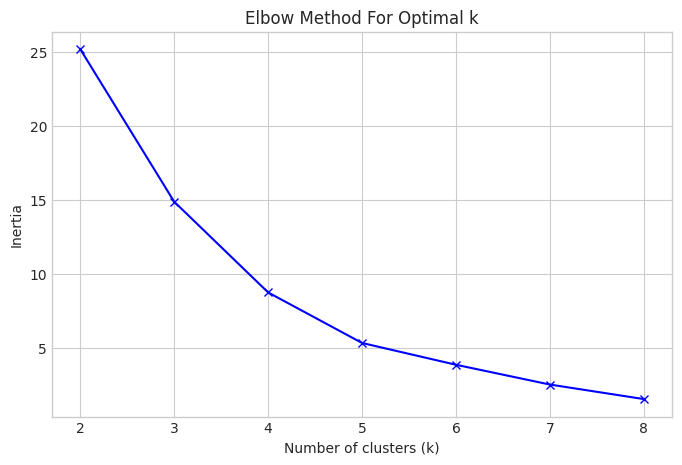


Based on the elbow plot, the optimal number of clusters appears to be 4.


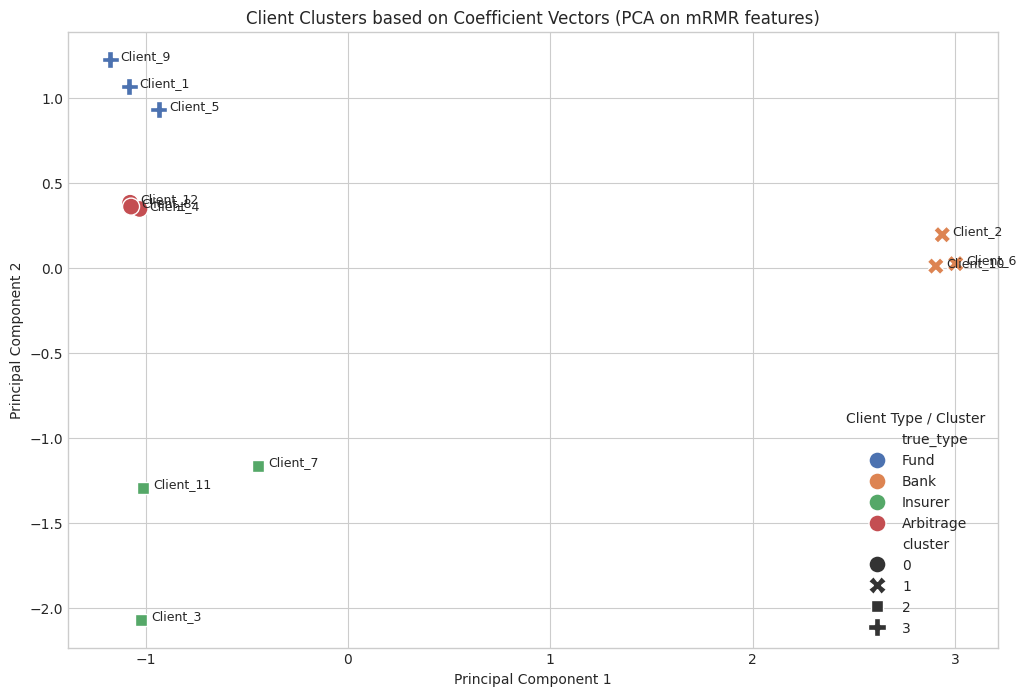


--- Cluster Assignments vs. True Type ---
feature    true_type  cluster
client                       
Client_12  Arbitrage        0
Client_4   Arbitrage        0
Client_8   Arbitrage        0
Client_2        Bank        1
Client_6        Bank        1
Client_10       Bank        1
Client_3     Insurer        2
Client_11    Insurer        2
Client_7     Insurer        2
Client_1        Fund        3
Client_5        Fund        3
Client_9        Fund        3


In [104]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Make sure to run: pip install mrmr_selection
from mrmr import mrmr_classif

# --- 1. Data Generation with FX Pairs and Volume ---

CLIENTS = [f'Client_{i}' for i in range(1, 13)]
CLIENT_TYPES = ['Fund', 'Bank', 'Insurer', 'Arbitrage']
FX_PAIRS = ['EURUSD', 'GBPUSD', 'USDJPY', 'AUDUSD']
client_to_type_map = {client: CLIENT_TYPES[(i % len(CLIENT_TYPES))] for i, client in enumerate(CLIENTS)}

def is_imm_date(date):
    """Checks if a date is an IMM date (third Wednesday of Mar, Jun, Sep, Dec)."""
    return date.month in [3, 6, 9, 12] and date.weekday() == 2 and 15 <= date.day <= 21

def generate_trade_events(num_days=2000):
    """
    Generates a DataFrame of simulated trade events with specific patterns,
    including FX pairs and trade volume.
    """
    trade_events = []
    start_date = datetime(2023, 1, 1)

    date_range = pd.to_datetime(pd.date_range(start=start_date, periods=num_days + 10))
    event_dates = pd.DataFrame(index=date_range)
    event_dates['is_imm'] = event_dates.index.map(is_imm_date)
    event_dates['is_mid'] = (event_dates.index.day >= 14) & (event_dates.index.day <= 16)
    event_dates['is_end'] = (event_dates.index + pd.DateOffset(days=3)).month != event_dates.index.month

    for day_offset in range(num_days):
        current_date = start_date + timedelta(days=day_offset)

        for client in CLIENTS:
            client_type = client_to_type_map[client]
            prob = 0.02
            fx_pair = random.choice(FX_PAIRS)
            volume = np.random.uniform(0.1, 0.3)

            if client_type == 'Fund' and any(event_dates.at[current_date + timedelta(days=d), 'is_imm'] for d in range(5)):
                prob = 0.9; volume = np.random.uniform(0.7, 1.0); fx_pair = 'EURUSD'
            elif client_type == 'Bank' and any(event_dates.at[current_date + timedelta(days=d), 'is_end'] for d in range(4)):
                prob = 0.95; volume = np.random.uniform(0.6, 0.9); fx_pair = 'GBPUSD'
            elif client_type == 'Insurer' and any(event_dates.at[current_date + timedelta(days=d), 'is_mid'] for d in range(3)):
                prob = 0.8; volume = np.random.uniform(0.2, 0.5); fx_pair = 'AUDUSD'
            elif client_type == 'Arbitrage' and any(event_dates.at[current_date + timedelta(days=d), 'is_imm'] for d in range(3, 8)):
                prob = 0.85; volume = np.random.uniform(0.5, 0.8); fx_pair = 'USDJPY'

            if random.random() < prob:
                trade_events.append({'time': current_date, 'client': client, 'fx_pair': fx_pair, 'volume': volume})

    return pd.DataFrame(trade_events)

# --- 2. Feature Engineering ---

def create_features_with_interactions(date_series, fx_pairs_list):
    """Creates time-based features and their interactions with FX pairs."""
    time_features_df = pd.DataFrame(index=date_series)
    time_features_df['imm_lead_1_to_3'] = time_features_df.index.map(lambda d: any(is_imm_date(d + timedelta(days=i)) for i in range(1, 4))).astype(int)
    time_features_df['imm_lead_4_to_6'] = time_features_df.index.map(lambda d: any(is_imm_date(d + timedelta(days=i)) for i in range(4, 7))).astype(int)
    time_features_df['end_lead_1_to_3'] = time_features_df.index.map(lambda d: any((d + timedelta(days=i)).month != d.month for i in range(1,4))).astype(int)

    days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
    for i, day_name in enumerate(days):
        time_features_df[f'is_{day_name}'] = (time_features_df.index.dayofweek == i).astype(int)

    for week_num in range(1, 5):
        time_features_df[f'is_week_{week_num}'] = ((time_features_df.index.day - 1) // 7 == week_num - 1).astype(int)

    final_features = pd.DataFrame(index=date_series)
    for pair in fx_pairs_list:
        for time_feature in time_features_df.columns:
            interaction_col_name = f"{time_feature}_X_{pair.replace('USD','')}"
            final_features[interaction_col_name] = time_features_df[time_feature]

    return final_features

# --- 3. Model Training Functions ---

def select_features_with_mrmr(X, y, k=8):
    """
    Selects the top k features using the mRMR algorithm.
    Returns a DataFrame with selected features and a list of their names.
    """
    selected_features_list = mrmr_classif(X=X, y=y, K=k, n_jobs=-1) # Use all available CPU cores
    X_selected = X[selected_features_list]
    return X_selected, selected_features_list

def train_probability_model(X_historical, y_prob, features_to_model):
    """
    Trains Part 1 of the model using L2 regularization and returns the results.
    """
    model_prob = LogisticRegression(penalty='l2', C=0.5, solver='liblinear', random_state=42)
    model_prob.fit(X_historical, y_prob)
    coeffs = pd.Series(model_prob.coef_[0], index=features_to_model)
    intercept_log_odds = model_prob.intercept_[0]
    baseline_prob = 1 / (1 + np.exp(-intercept_log_odds))
    return model_prob, coeffs, baseline_prob

def train_size_model(client_trades):
    """Trains Part 2 of the model (volume and pair)."""
    if client_trades.empty:
        return {}, None
    averages_by_pair = client_trades.groupby('fx_pair')['volume'].mean().to_dict()
    most_frequent = client_trades['fx_pair'].mode()[0]
    return averages_by_pair, most_frequent

# --- 4. Main Execution: Data, Training, and Analysis ---

# Generate Data
trade_df = generate_trade_events(num_days=1095)
all_days = pd.date_range(start=trade_df['time'].min(), end=trade_df['time'].max())

# Create ALL possible features for the historical period
X_historical_full = create_features_with_interactions(all_days, FX_PAIRS)

# Dictionaries to store models, results, and selected features for each client
probability_models, volume_averages_by_pair, most_frequent_pair = {}, {}, {}
model_results_list, baseline_results_list = [], []
client_feature_selectors = {} # Store the mRMR-selected features for each client

# The number of features to select. This is a key hyperparameter.
NUM_FEATURES_TO_SELECT = 10

print("--- Training Two-Part Models for Each Client using mRMR Feature Selection ---")
for client in CLIENTS:
    client_trades = trade_df[trade_df['client'] == client]

    # FIX: Ensure y_prob has the same DatetimeIndex as X_historical_full
    y_prob = pd.Series(all_days.isin(pd.to_datetime(client_trades['time'])), index=all_days).astype(int)

    # mRMR requires at least two classes in the target variable to work.
    if len(y_prob.unique()) < 2:
        print(f"Skipping client {client} due to insufficient trading data (target has only one class).")
        continue

    # --- FEATURE SELECTION STEP using mRMR ---
    X_historical_selected, selected_feature_names = select_features_with_mrmr(
        X_historical_full, y_prob, k=NUM_FEATURES_TO_SELECT
    )
    client_feature_selectors[client] = selected_feature_names

    # --- Train model on the SELECTED features ---
    model_prob, significant_coeffs, baseline_prob = train_probability_model(
        X_historical_selected, y_prob, selected_feature_names
    )

    probability_models[client] = model_prob
    for feature, coef_val in significant_coeffs.items():
        model_results_list.append({'client': client, 'client_type': client_to_type_map[client], 'feature': feature, 'coefficient': coef_val})
    baseline_results_list.append({'client': client, 'client_type': client_to_type_map[client], 'baseline_probability': baseline_prob})

    volume_averages_by_pair[client], most_frequent_pair[client] = train_size_model(client_trades)

print("Training complete.")

# --- 4a. Model Results Analysis ---
print("\n" + "="*70); print("           FEATURES SELECTED BY mRMR (PER CLIENT)             "); print("="*70)
mrmr_results = []
for client, features in client_feature_selectors.items():
    for i, feature in enumerate(features):
        mrmr_results.append({
            'client': client,
            'client_type': client_to_type_map[client],
            'rank': i + 1,
            'feature': feature
        })
if mrmr_results:
    mrmr_df = pd.DataFrame(mrmr_results)
    print(mrmr_df.pivot_table(index=['client', 'client_type'], columns='rank', values='feature', aggfunc='first').to_string())
else:
    print("No features were selected (check data).")

results_df = pd.DataFrame(model_results_list)
print("\n" + "="*70); print("      PART 1: PROBABILITY MODEL RESULTS (COEFFICIENTS)      "); print("="*70)
print(results_df.to_string())
print("\n" + "="*70); print("             PART 2: SIZE MODEL RESULTS (AVERAGES BY PAIR)          "); print("="*70)
volume_summary = [{'client': c, 'client_type': client_to_type_map[c], 'fx_pair': p, 'average_volume': v} for c, d in volume_averages_by_pair.items() for p, v in d.items()]
print(pd.DataFrame(volume_summary).to_string())

# --- 4b. Coefficient Matrix ---
print("\n" + "="*70); print("                 CLIENT-FEATURE COEFFICIENT MATRIX              "); print("="*70)
coeff_matrix = results_df.pivot_table(index='client', columns='feature', values='coefficient').fillna(0)
print(coeff_matrix)
print("="*70 + "\n")

# --- 5. Forecasting ---

def calculate_true_forecast(future_dates_range, last_date):
    """Calculates the ground truth forecast based on simulation rules."""
    true_forecast_df = pd.DataFrame(index=future_dates_range)
    date_range_future = pd.to_datetime(pd.date_range(start=last_date + timedelta(days=1), periods=len(future_dates_range) + 10))
    event_dates_future = pd.DataFrame(index=date_range_future)
    event_dates_future['is_imm'] = event_dates_future.index.map(is_imm_date)
    event_dates_future['is_mid'] = (event_dates_future.index.day >= 14) & (event_dates_future.index.day <= 16)
    event_dates_future['is_end'] = (event_dates_future.index + pd.DateOffset(days=3)).month != event_dates_future.index.month

    for client_type, client_name in clients_to_predict.items():
        true_volumes = []
        for date in future_dates_range:
            true_prob, true_vol = 0.02, 0.2
            if client_type == 'Fund' and any(event_dates_future.at[date + timedelta(days=d), 'is_imm'] for d in range(5)):
                true_prob, true_vol = 0.9, 0.85
            elif client_type == 'Bank' and any(event_dates_future.at[date + timedelta(days=d), 'is_end'] for d in range(4)):
                true_prob, true_vol = 0.95, 0.75
            elif client_type == 'Insurer' and any(event_dates_future.at[date + timedelta(days=d), 'is_mid'] for d in range(3)):
                true_prob, true_vol = 0.8, 0.35
            elif client_type == 'Arbitrage' and any(event_dates_future.at[date + timedelta(days=d), 'is_imm'] for d in range(3, 8)):
                true_prob, true_vol = 0.85, 0.65
            true_volumes.append(true_prob * true_vol)
        true_forecast_df[f'{client_name}_{client_type}'] = true_volumes
    return true_forecast_df

last_date = all_days.max()
future_dates_range = pd.date_range(start=last_date + timedelta(days=1), periods=90)
X_future_full = create_features_with_interactions(future_dates_range, FX_PAIRS)

clients_to_predict = {'Fund': 'Client_1', 'Bank': 'Client_2', 'Insurer': 'Client_3', 'Arbitrage': 'Client_4'}
prediction_df = pd.DataFrame(index=future_dates_range)

for client_type, client_name in clients_to_predict.items():
    if client_name in probability_models:
        prob_model = probability_models[client_name]

        # Select the same features for the future data that mRMR chose during training
        selected_features = client_feature_selectors[client_name]
        X_future_selected = X_future_full[selected_features]

        trade_probabilities = prob_model.predict_proba(X_future_selected)[:, 1]
        primary_pair = most_frequent_pair.get(client_name)
        avg_volume = volume_averages_by_pair.get(client_name, {}).get(primary_pair, 0)
        prediction_df[f'{client_name}_{client_type}'] = trade_probabilities * avg_volume

# --- 6. Visualization ---

def plot_forecasts(prediction_df, true_forecast_df=None):
    """Visualizes the model's forecast, optionally with a ground truth comparison."""
    client_colors = {'Fund': '#4b0082', 'Bank': '#008080', 'Insurer': '#55a630', 'Arbitrage': '#ff8c00'}
    region_colors = {'IMM Date': 'palegreen', 'Month-End': 'lightcoral'}
    num_clients = len(clients_to_predict)

    fig, axes = plt.subplots(num_clients, 1, figsize=(18, 4 * num_clients), sharex=True, sharey=True)
    title = 'Forecasted vs. True Expected Daily Volume (using mRMR features)'
    fig.suptitle(title, fontsize=20, y=0.95)

    prediction_df_reset = prediction_df.reset_index().rename(columns={'index': 'date'})
    if true_forecast_df is not None:
        true_forecast_df_reset = true_forecast_df.reset_index().rename(columns={'index': 'date'})

    for i, (client_type, client_name) in enumerate(clients_to_predict.items()):
        ax = axes[i]
        col_name = f'{client_name}_{client_type}'

        ax.bar(prediction_df_reset.index, prediction_df_reset[col_name], color=client_colors[client_type], label=f'Model Forecast')

        if true_forecast_df is not None:
            ax.plot(true_forecast_df_reset.index, true_forecast_df_reset[col_name], color='black', linestyle='--', marker='.', markersize=4, label='True Expected Volume')

        for date_idx, date in enumerate(prediction_df_reset['date']):
            if is_imm_date(date): ax.axvspan(date_idx - 0.5, date_idx + 0.5, color=region_colors['IMM Date'], alpha=0.3, zorder=0, lw=0)
            if date.is_month_end: ax.axvspan(date_idx - 0.5, date_idx + 0.5, color=region_colors['Month-End'], alpha=0.3, zorder=0, lw=0)

        ax.set_title(f'Forecast for: {client_name} ({client_type})', fontsize=14)
        ax.set_ylabel('Expected Volume')
        ax.grid(axis='y', linestyle='--', alpha=0.7)

        handles, labels = ax.get_legend_handles_labels()
        if true_forecast_df is not None:
            region_patches = [plt.Rectangle((0,0),1,1, color=color, alpha=0.3) for color in region_colors.values()]
            handles.extend(region_patches); labels.extend(region_colors.keys())
        ax.legend(handles=handles, labels=labels, loc='upper left')

    axes[-1].set_xlabel('Day in Forecast Horizon (0 = Tomorrow)', fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()

# Run Main Visualization
true_forecast = calculate_true_forecast(future_dates_range, last_date)
plot_forecasts(prediction_df, true_forecast_df=true_forecast)

# --- 7. Fund Client Analysis Visualization ---
print("\n" + "="*70); print("              ANALYSIS OF 'FUND' CLIENT COEFFICIENTS              "); print("="*70)
fund_clients = [client for client, ctype in client_to_type_map.items() if ctype == 'Fund']
fund_coeffs = coeff_matrix.loc[fund_clients]

# Select only features where at least one fund has a non-zero coefficient
fund_coeffs = fund_coeffs.loc[:, (fund_coeffs != 0).any(axis=0)]

plt.figure(figsize=(16, 8))
sns.heatmap(fund_coeffs, cmap='viridis', annot=True, fmt='.2f', linewidths=.5)
plt.title('Coefficient Heatmap for all "Fund" Clients (mRMR Features)', fontsize=16)
plt.xlabel('Feature')
plt.ylabel('Client')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- 8. Client Clustering Analysis ---
print("\n" + "="*70); print("               CLIENT CLUSTERING ANALYSIS (K-MEANS)               "); print("="*70)

# Elbow method to find optimal k
inertia = []
K = range(2, 9)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(coeff_matrix)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

# Based on the elbow plot, choose the optimal k
optimal_k = 4
print(f"\nBased on the elbow plot, the optimal number of clusters appears to be {optimal_k}.")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(coeff_matrix)
coeff_matrix['cluster'] = clusters
coeff_matrix['true_type'] = coeff_matrix.index.map(client_to_type_map)

# Visualize clusters with PCA
pca = PCA(n_components=2, random_state=42)
principal_components = pca.fit_transform(coeff_matrix.drop(columns=['cluster', 'true_type']))
pca_df = pd.DataFrame(data=principal_components, columns=['PC 1', 'PC 2'], index=coeff_matrix.index)
pca_df = pd.concat([pca_df, coeff_matrix[['cluster', 'true_type']]], axis=1)

plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC 1', y='PC 2', hue='true_type', style='cluster', data=pca_df, s=150, palette='deep')
# Add client labels
for i, client in enumerate(pca_df.index):
    plt.text(pca_df['PC 1'][i]+0.05, pca_df['PC 2'][i], client, fontsize=9)

plt.title('Client Clusters based on Coefficient Vectors (PCA on mRMR features)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Client Type / Cluster')
plt.grid(True)
plt.show()

print("\n--- Cluster Assignments vs. True Type ---")
print(coeff_matrix[['true_type', 'cluster']].sort_values(by='cluster'))

In [101]:
pip install pandas numpy matplotlib seaborn scikit-learn mrmr_selection

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 2.4 MB/s eta 0:00:00


--- Training Two-Part Models (Currency-Agnostic) using mRMR ---


100%|██████████| 6/6 [00:00<00:00, 44.33it/s]


Training complete.

           FEATURES SELECTED BY mRMR (PER CLIENT)             
rank                                 1                2                3          4                5                6
client    client_type                                                                                                
Client_1  Fund         imm_lead_1_to_3  imm_lead_4_to_6        is_week_3     is_Thu           is_Fri        is_week_4
Client_10 Bank         end_lead_1_to_3        is_week_4           is_Thu  is_week_2        is_week_3        is_week_1
Client_11 Insurer            is_week_2  imm_lead_4_to_6  imm_lead_1_to_3  is_week_4        is_week_1  end_lead_1_to_3
Client_12 Arbitrage    imm_lead_4_to_6  imm_lead_1_to_3        is_week_2     is_Tue  end_lead_1_to_3           is_Mon
Client_2  Bank         end_lead_1_to_3        is_week_4           is_Wed  is_week_2        is_week_1        is_week_3
Client_3  Insurer            is_week_2  imm_lead_4_to_6  imm_lead_1_to_3  is_week_1        

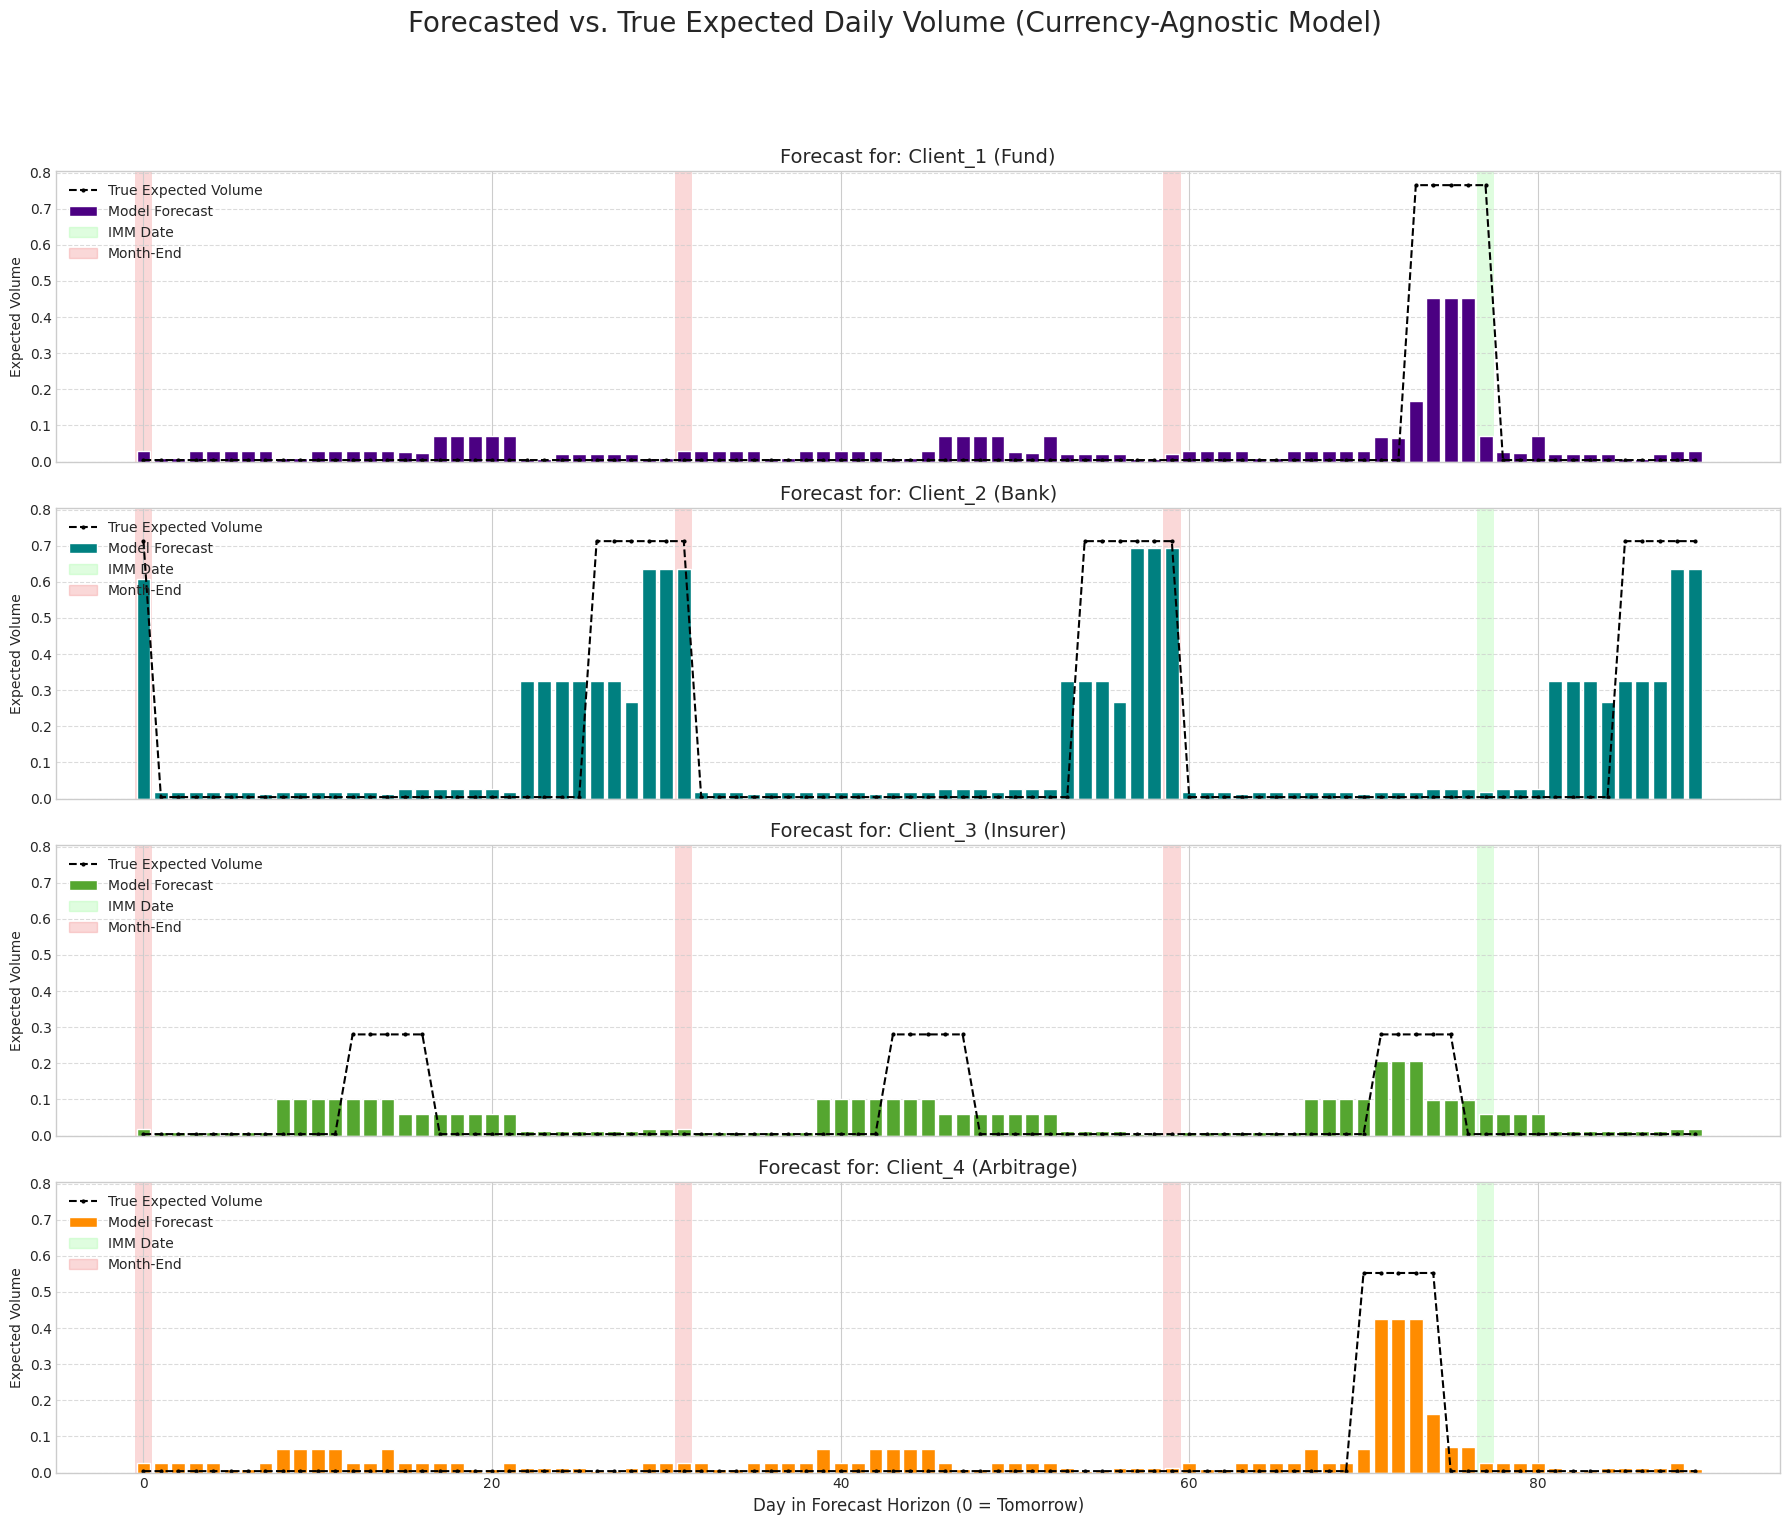


              ANALYSIS OF 'FUND' CLIENT COEFFICIENTS              


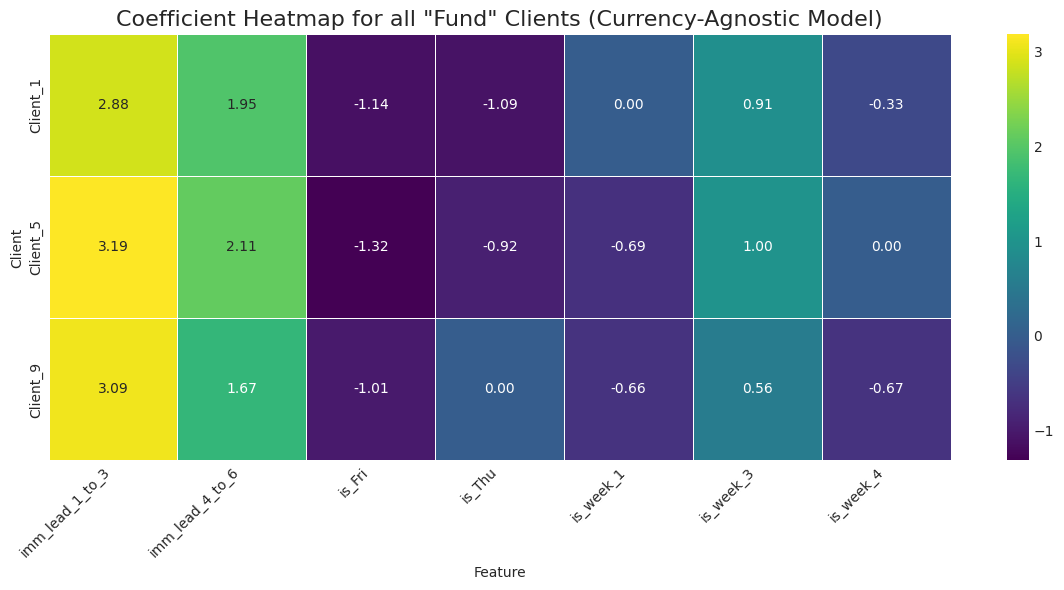


               CLIENT CLUSTERING ANALYSIS (K-MEANS)               


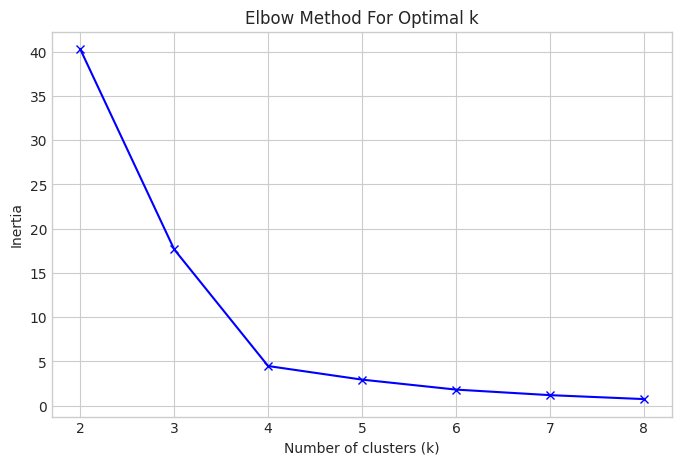


Based on the elbow plot, the optimal number of clusters appears to be 4.


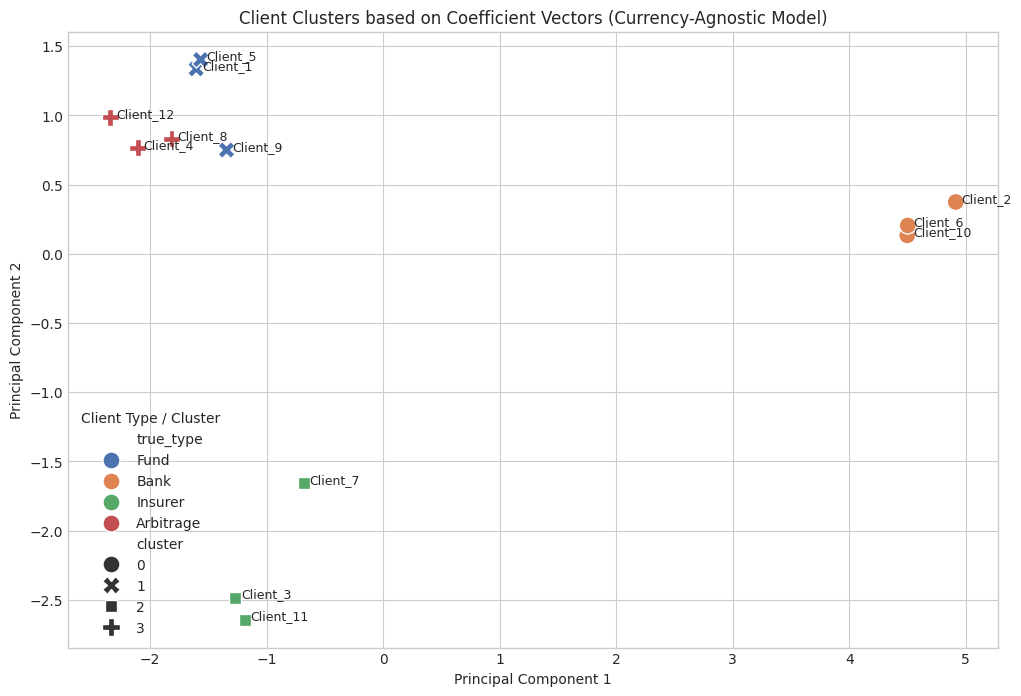


--- Cluster Assignments vs. True Type ---
feature    true_type  cluster
client                       
Client_10       Bank        0
Client_2        Bank        0
Client_6        Bank        0
Client_5        Fund        1
Client_9        Fund        1
Client_1        Fund        1
Client_3     Insurer        2
Client_11    Insurer        2
Client_7     Insurer        2
Client_12  Arbitrage        3
Client_4   Arbitrage        3
Client_8   Arbitrage        3


In [105]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Make sure to run: pip install mrmr_selection
from mrmr import mrmr_classif

# --- 1. Data Generation (Currency Removed) ---

CLIENTS = [f'Client_{i}' for i in range(1, 13)]
CLIENT_TYPES = ['Fund', 'Bank', 'Insurer', 'Arbitrage']
# The FX_PAIRS list has been removed.
client_to_type_map = {client: CLIENT_TYPES[(i % len(CLIENT_TYPES))] for i, client in enumerate(CLIENTS)}

def is_imm_date(date):
    """Checks if a date is an IMM date (third Wednesday of Mar, Jun, Sep, Dec)."""
    return date.month in [3, 6, 9, 12] and date.weekday() == 2 and 15 <= date.day <= 21

def generate_trade_events(num_days=2000):
    """
    Generates a DataFrame of simulated trade events without currency information.
    """
    trade_events = []
    start_date = datetime(2023, 1, 1)

    date_range = pd.to_datetime(pd.date_range(start=start_date, periods=num_days + 10))
    event_dates = pd.DataFrame(index=date_range)
    event_dates['is_imm'] = event_dates.index.map(is_imm_date)
    event_dates['is_mid'] = (event_dates.index.day >= 14) & (event_dates.index.day <= 16)
    event_dates['is_end'] = (event_dates.index + pd.DateOffset(days=3)).month != event_dates.index.month

    for day_offset in range(num_days):
        current_date = start_date + timedelta(days=day_offset)

        for client in CLIENTS:
            client_type = client_to_type_map[client]
            prob = 0.02
            volume = np.random.uniform(0.1, 0.3)

            # The fx_pair assignments have been removed.
            if client_type == 'Fund' and any(event_dates.at[current_date + timedelta(days=d), 'is_imm'] for d in range(5)):
                prob = 0.9; volume = np.random.uniform(0.7, 1.0)
            elif client_type == 'Bank' and any(event_dates.at[current_date + timedelta(days=d), 'is_end'] for d in range(4)):
                prob = 0.95; volume = np.random.uniform(0.6, 0.9)
            elif client_type == 'Insurer' and any(event_dates.at[current_date + timedelta(days=d), 'is_mid'] for d in range(3)):
                prob = 0.8; volume = np.random.uniform(0.2, 0.5)
            elif client_type == 'Arbitrage' and any(event_dates.at[current_date + timedelta(days=d), 'is_imm'] for d in range(3, 8)):
                prob = 0.85; volume = np.random.uniform(0.5, 0.8)

            if random.random() < prob:
                # The 'fx_pair' key has been removed from the event dictionary.
                trade_events.append({'time': current_date, 'client': client, 'volume': volume})

    return pd.DataFrame(trade_events)

# --- 2. Feature Engineering (Simplified) ---

def create_time_features(date_series):
    """Creates only time-based features, without currency interactions."""
    time_features_df = pd.DataFrame(index=date_series)
    time_features_df['imm_lead_1_to_3'] = time_features_df.index.map(lambda d: any(is_imm_date(d + timedelta(days=i)) for i in range(1, 4))).astype(int)
    time_features_df['imm_lead_4_to_6'] = time_features_df.index.map(lambda d: any(is_imm_date(d + timedelta(days=i)) for i in range(4, 7))).astype(int)
    time_features_df['end_lead_1_to_3'] = time_features_df.index.map(lambda d: any((d + timedelta(days=i)).month != d.month for i in range(1,4))).astype(int)

    days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
    for i, day_name in enumerate(days):
        time_features_df[f'is_{day_name}'] = (time_features_df.index.dayofweek == i).astype(int)

    for week_num in range(1, 5):
        time_features_df[f'is_week_{week_num}'] = ((time_features_df.index.day - 1) // 7 == week_num - 1).astype(int)

    # The interaction loop has been removed. We return the time features directly.
    return time_features_df

# --- 3. Model Training Functions (Volume Model Simplified) ---

def select_features_with_mrmr(X, y, k=8):
    """
    Selects the top k features using the mRMR algorithm.
    Returns a DataFrame with selected features and a list of their names.
    """
    selected_features_list = mrmr_classif(X=X, y=y, K=k, n_jobs=-1)
    X_selected = X[selected_features_list]
    return X_selected, selected_features_list

def train_probability_model(X_historical, y_prob, features_to_model):
    """
    Trains Part 1 of the model using L2 regularization and returns the results.
    """
    model_prob = LogisticRegression(penalty='l2', C=0.5, solver='liblinear', random_state=42)
    model_prob.fit(X_historical, y_prob)
    coeffs = pd.Series(model_prob.coef_[0], index=features_to_model)
    intercept_log_odds = model_prob.intercept_[0]
    baseline_prob = 1 / (1 + np.exp(-intercept_log_odds))
    return model_prob, coeffs, baseline_prob

def train_size_model(client_trades):
    """
    Trains Part 2 of the model. Simplified to calculate a single average volume.
    """
    if client_trades.empty or client_trades['volume'].isnull().all():
        return 0
    # Calculate a single overall average volume.
    overall_average_volume = client_trades['volume'].mean()
    return overall_average_volume

# --- 4. Main Execution: Data, Training, and Analysis ---

# Generate Data
trade_df = generate_trade_events(num_days=1095)
all_days = pd.date_range(start=trade_df['time'].min(), end=trade_df['time'].max())

# Create the simplified time-based features
X_historical_full = create_time_features(all_days)

# Dictionaries to store models and results
probability_models, volume_averages = {}, {}
model_results_list, baseline_results_list = [], []
client_feature_selectors = {}

# The number of features to select. The total number of features is now much smaller.
# Total features are ~12, so k should be smaller.
NUM_FEATURES_TO_SELECT = 6

print("--- Training Two-Part Models (Currency-Agnostic) using mRMR ---")
for client in CLIENTS:
    client_trades = trade_df[trade_df['client'] == client]

    y_prob = pd.Series(all_days.isin(pd.to_datetime(client_trades['time'])), index=all_days).astype(int)

    if len(y_prob.unique()) < 2:
        print(f"Skipping client {client} due to insufficient trading data.")
        continue

    X_historical_selected, selected_feature_names = select_features_with_mrmr(
        X_historical_full, y_prob, k=min(NUM_FEATURES_TO_SELECT, len(X_historical_full.columns))
    )
    client_feature_selectors[client] = selected_feature_names

    model_prob, significant_coeffs, baseline_prob = train_probability_model(
        X_historical_selected, y_prob, selected_feature_names
    )

    probability_models[client] = model_prob
    for feature, coef_val in significant_coeffs.items():
        model_results_list.append({'client': client, 'client_type': client_to_type_map[client], 'feature': feature, 'coefficient': coef_val})
    baseline_results_list.append({'client': client, 'client_type': client_to_type_map[client], 'baseline_probability': baseline_prob})

    # Store the single average volume
    volume_averages[client] = train_size_model(client_trades)

print("Training complete.")

# --- 4a. Model Results Analysis ---
print("\n" + "="*70); print("           FEATURES SELECTED BY mRMR (PER CLIENT)             "); print("="*70)
mrmr_results = []
for client, features in client_feature_selectors.items():
    for i, feature in enumerate(features):
        mrmr_results.append({
            'client': client, 'client_type': client_to_type_map[client], 'rank': i + 1, 'feature': feature
        })
if mrmr_results:
    mrmr_df = pd.DataFrame(mrmr_results)
    print(mrmr_df.pivot_table(index=['client', 'client_type'], columns='rank', values='feature', aggfunc='first').to_string())

results_df = pd.DataFrame(model_results_list)
print("\n" + "="*70); print("      PART 1: PROBABILITY MODEL RESULTS (COEFFICIENTS)      "); print("="*70)
print(results_df.to_string())
print("\n" + "="*70); print("             PART 2: SIZE MODEL RESULTS (AVERAGE VOLUME)          "); print("="*70)
volume_summary = [{'client': c, 'client_type': client_to_type_map[c], 'average_volume': v} for c, v in volume_averages.items()]
print(pd.DataFrame(volume_summary).to_string())

# --- 4b. Coefficient Matrix ---
print("\n" + "="*70); print("                 CLIENT-FEATURE COEFFICIENT MATRIX              "); print("="*70)
coeff_matrix = results_df.pivot_table(index='client', columns='feature', values='coefficient').fillna(0)
print(coeff_matrix)
print("="*70 + "\n")

# --- 5. Forecasting ---

def calculate_true_forecast(future_dates_range, last_date):
    """Calculates the ground truth forecast based on simulation rules."""
    true_forecast_df = pd.DataFrame(index=future_dates_range)
    date_range_future = pd.to_datetime(pd.date_range(start=last_date + timedelta(days=1), periods=len(future_dates_range) + 10))
    event_dates_future = pd.DataFrame(index=date_range_future)
    event_dates_future['is_imm'] = event_dates_future.index.map(is_imm_date)
    event_dates_future['is_mid'] = (event_dates_future.index.day >= 14) & (event_dates_future.index.day <= 16)
    event_dates_future['is_end'] = (event_dates_future.index + pd.DateOffset(days=3)).month != event_dates_future.index.month

    for client_type, client_name in clients_to_predict.items():
        true_volumes = []
        for date in future_dates_range:
            true_prob, true_vol = 0.02, 0.2
            if client_type == 'Fund' and any(event_dates_future.at[date + timedelta(days=d), 'is_imm'] for d in range(5)):
                true_prob, true_vol = 0.9, 0.85
            elif client_type == 'Bank' and any(event_dates_future.at[date + timedelta(days=d), 'is_end'] for d in range(4)):
                true_prob, true_vol = 0.95, 0.75
            elif client_type == 'Insurer' and any(event_dates_future.at[date + timedelta(days=d), 'is_mid'] for d in range(3)):
                true_prob, true_vol = 0.8, 0.35
            elif client_type == 'Arbitrage' and any(event_dates_future.at[date + timedelta(days=d), 'is_imm'] for d in range(3, 8)):
                true_prob, true_vol = 0.85, 0.65
            true_volumes.append(true_prob * true_vol)
        true_forecast_df[f'{client_name}_{client_type}'] = true_volumes
    return true_forecast_df

last_date = all_days.max()
future_dates_range = pd.date_range(start=last_date + timedelta(days=1), periods=90)
X_future_full = create_time_features(future_dates_range)

clients_to_predict = {'Fund': 'Client_1', 'Bank': 'Client_2', 'Insurer': 'Client_3', 'Arbitrage': 'Client_4'}
prediction_df = pd.DataFrame(index=future_dates_range)

for client_type, client_name in clients_to_predict.items():
    if client_name in probability_models:
        prob_model = probability_models[client_name]

        selected_features = client_feature_selectors[client_name]
        X_future_selected = X_future_full[selected_features]

        trade_probabilities = prob_model.predict_proba(X_future_selected)[:, 1]

        # Use the new simplified average volume
        avg_volume = volume_averages.get(client_name, 0)
        prediction_df[f'{client_name}_{client_type}'] = trade_probabilities * avg_volume

# --- 6. Visualization ---

def plot_forecasts(prediction_df, true_forecast_df=None):
    """Visualizes the model's forecast, optionally with a ground truth comparison."""
    client_colors = {'Fund': '#4b0082', 'Bank': '#008080', 'Insurer': '#55a630', 'Arbitrage': '#ff8c00'}
    region_colors = {'IMM Date': 'palegreen', 'Month-End': 'lightcoral'}
    num_clients = len(clients_to_predict)

    fig, axes = plt.subplots(num_clients, 1, figsize=(18, 4 * num_clients), sharex=True, sharey=True)
    title = 'Forecasted vs. True Expected Daily Volume (Currency-Agnostic Model)'
    fig.suptitle(title, fontsize=20, y=0.95)

    prediction_df_reset = prediction_df.reset_index().rename(columns={'index': 'date'})
    if true_forecast_df is not None:
        true_forecast_df_reset = true_forecast_df.reset_index().rename(columns={'index': 'date'})

    for i, (client_type, client_name) in enumerate(clients_to_predict.items()):
        ax = axes[i]
        col_name = f'{client_name}_{client_type}'

        ax.bar(prediction_df_reset.index, prediction_df_reset[col_name], color=client_colors[client_type], label=f'Model Forecast')

        if true_forecast_df is not None:
            ax.plot(true_forecast_df_reset.index, true_forecast_df_reset[col_name], color='black', linestyle='--', marker='.', markersize=4, label='True Expected Volume')

        for date_idx, date in enumerate(prediction_df_reset['date']):
            if is_imm_date(date): ax.axvspan(date_idx - 0.5, date_idx + 0.5, color=region_colors['IMM Date'], alpha=0.3, zorder=0, lw=0)
            if date.is_month_end: ax.axvspan(date_idx - 0.5, date_idx + 0.5, color=region_colors['Month-End'], alpha=0.3, zorder=0, lw=0)

        ax.set_title(f'Forecast for: {client_name} ({client_type})', fontsize=14); ax.set_ylabel('Expected Volume'); ax.grid(axis='y', linestyle='--', alpha=0.7)

        handles, labels = ax.get_legend_handles_labels()
        if true_forecast_df is not None:
            region_patches = [plt.Rectangle((0,0),1,1, color=color, alpha=0.3) for color in region_colors.values()]
            handles.extend(region_patches); labels.extend(region_colors.keys())
        ax.legend(handles=handles, labels=labels, loc='upper left')

    axes[-1].set_xlabel('Day in Forecast Horizon (0 = Tomorrow)', fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()

# Run Main Visualization
true_forecast = calculate_true_forecast(future_dates_range, last_date)
plot_forecasts(prediction_df, true_forecast_df=true_forecast)

# --- 7. Fund Client Analysis Visualization ---
print("\n" + "="*70); print("              ANALYSIS OF 'FUND' CLIENT COEFFICIENTS              "); print("="*70)
fund_clients = [client for client, ctype in client_to_type_map.items() if ctype == 'Fund']
fund_coeffs = coeff_matrix.loc[fund_clients]

fund_coeffs = fund_coeffs.loc[:, (fund_coeffs != 0).any(axis=0)]

plt.figure(figsize=(12, 6)) # Adjusted size for fewer features
sns.heatmap(fund_coeffs, cmap='viridis', annot=True, fmt='.2f', linewidths=.5)
plt.title('Coefficient Heatmap for all "Fund" Clients (Currency-Agnostic Model)', fontsize=16)
plt.xlabel('Feature')
plt.ylabel('Client')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- 8. Client Clustering Analysis ---
print("\n" + "="*70); print("               CLIENT CLUSTERING ANALYSIS (K-MEANS)               "); print("="*70)

inertia = []
K = range(2, 9)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(coeff_matrix)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

optimal_k = 4
print(f"\nBased on the elbow plot, the optimal number of clusters appears to be {optimal_k}.")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(coeff_matrix)
coeff_matrix['cluster'] = clusters
coeff_matrix['true_type'] = coeff_matrix.index.map(client_to_type_map)

pca = PCA(n_components=2, random_state=42)
principal_components = pca.fit_transform(coeff_matrix.drop(columns=['cluster', 'true_type']))
pca_df = pd.DataFrame(data=principal_components, columns=['PC 1', 'PC 2'], index=coeff_matrix.index)
pca_df = pd.concat([pca_df, coeff_matrix[['cluster', 'true_type']]], axis=1)

plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC 1', y='PC 2', hue='true_type', style='cluster', data=pca_df, s=150, palette='deep')

for i, client in enumerate(pca_df.index):
    plt.text(pca_df['PC 1'][i]+0.05, pca_df['PC 2'][i], client, fontsize=9)

plt.title('Client Clusters based on Coefficient Vectors (Currency-Agnostic Model)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Client Type / Cluster')
plt.grid(True)
plt.show()

print("\n--- Cluster Assignments vs. True Type ---")
print(coeff_matrix[['true_type', 'cluster']].sort_values(by='cluster'))